# Psychological Non-Standardness in Top Literary Authors
**K. Sh. Karimov, 2026**

---
## Pipeline
```
0.  Setup & Data Loading
1.  Data Quality Audit
2.  Baseline Statistics          (median+IQR primary)
3.  Era Analysis                 (Holm-corrected M-W U)
4.  Gender Analysis              (with Unknown-rate audit)
5.  Tag Co-occurrence            (null-masked Jaccard)
6.  Temporal Trends
7.  Goodreads Correlations       (era-partial Spearman)
8.  Clustering                   (K-modes + Hamming PCA)
9.  Original Hypotheses          (with Holm + confound notes)
10. Sensitivity Analysis         (conf ≥ 0.65 / 0.75)
11. Custom Tags Analysis
12. Text Profiles (TF-IDF)
13. Export
14. Predictive Modelling         (Logistic Regression + Feature Importance)
```


---
## 0. Setup & Data Loading

In [1]:
#install
!pip install pandas numpy matplotlib seaborn scipy scikit-learn kmodes gender-guesser statsmodels adjustText

import json, re, warnings
from collections import Counter
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact, spearmanr
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.feature_extraction.text import TfidfVectorizer
from statsmodels.stats.multitest import multipletests  # Holm correction

warnings.filterwarnings('ignore')

# ── v3: updated to JSON ────────────────────────────────────────────────────
DATA_PATH = 'authors_annotated.json'
FIGS_DIR  = Path('figures')
FIGS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150, 'figure.facecolor': 'white',
    'axes.facecolor': 'white', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'sans-serif', 'font.size': 11,
})

ERA_COLORS    = {'XIX': '#3B6D11', 'XX': '#185FA5', 'XXI': '#993C1D'}
GENDER_COLORS = {'M': '#185FA5', 'F': '#993556', 'Unknown': '#888780'}
CLUSTER_PAL   = ['#7F77DD', '#1D9E75', '#D85A30', '#D4537E', '#888780']

print('Setup complete.')


Setup complete.


In [2]:
#pd.read_json() instead of pd.read_csv()
df_raw = pd.read_json(DATA_PATH)
print(f'Rows: {len(df_raw)}  |  Columns: {len(df_raw.columns)}')

TAGS = [
    'tag_depression','tag_bipolar','tag_schizophrenia','tag_anxiety',
    'tag_ptsd','tag_substance_abuse','tag_suicide','tag_suicide_attempt',
    'tag_institutionalized','tag_childhood_trauma','tag_war_experience',
    'tag_poverty_extreme','tag_chronic_illness','tag_disability',
    'tag_occultism','tag_spiritualism','tag_religious_mania',
    'tag_cult_involvement','tag_theosophy_mysticism',
    'tag_non_traditional_relationship','tag_homosexuality_taboo_era',
    'tag_obsessive_attachment','tag_celibacy_pathological',
    'tag_incest_adjacent','tag_alter_ego_documented',
    'tag_depersonalization','tag_voluntary_isolation',
    'tag_pathological_gambling','tag_legal_troubles',
    'tag_imprisonment','tag_exile','tag_extremist_views',
    'tag_violence_documented','tag_self_destructive_pattern',
    'tag_eating_disorder','tag_paranoia','tag_messiah_complex',
    'tag_nihilism_explicit'
]
TAG_SHORT = {t: t.replace('tag_', '') for t in TAGS}
ERA_MAP = {'19': 'XIX', '20': 'XX', '21': 'XXI'}
df_raw['era'] = df_raw['era'].astype(str).map(ERA_MAP).fillna('Unknown')

# Parse flat tag columns from predefined_tags_json if not already flat
if 'tag_depression' not in df_raw.columns and 'predefined_tags_json' in df_raw.columns:
    expanded = (df_raw['predefined_tags_json']
                .apply(lambda x: json.loads(x) if isinstance(x, str) else {})
                .apply(pd.Series))
    expanded.columns = ['tag_' + c for c in expanded.columns]
    df_raw = pd.concat([df_raw, expanded], axis=1)

df_raw['score'] = pd.to_numeric(df_raw['standardness_score'], errors='coerce')
df_raw['conf']  = pd.to_numeric(df_raw['confidence'], errors='coerce')
def parse_born(val):
    if pd.isna(val) or str(val).strip() == '':
        return np.nan
    m = re.search(r'\b(1[678]\d{2}|19[0-9]\d|200\d)\b', str(val))
    return int(m.group()) if m else np.nan

def parse_bio(text):
    if not isinstance(text, str): return np.nan
    m = re.search(r'\b(1[78]\d{2}|19[0-8]\d|1990)\b', text)
    return int(m.group()) if m else np.nan

if 'born' in df_raw.columns:
    df_raw['birth_year'] = df_raw['born'].apply(parse_born)
    missing = df_raw['birth_year'].isna()
    if missing.any() and 'bio_text' in df_raw.columns:
        df_raw.loc[missing, 'birth_year'] = df_raw.loc[missing, 'bio_text'].apply(parse_bio)
    n_born = (~df_raw['birth_year'].isna()).sum()
    print(f'birth_year resolved for {n_born}/{len(df_raw)} authors (used for decade only)')
else:
    df_raw['birth_year'] = df_raw.get('bio_text', pd.Series(dtype=str)).apply(parse_bio)

df_raw['decade'] = (df_raw['birth_year'] // 10 * 10).astype('Int64')
gender_map = {'male': 'M', 'female': 'F', 'unknown': 'Unknown',
              'M': 'M', 'F': 'F', 'Unknown': 'Unknown'}
if 'gender' in df_raw.columns:
    df_raw['gender'] = df_raw['gender'].map(gender_map).fillna('Unknown')

df = df_raw[df_raw['score'].notna()].copy()

# Coerce tags to nullable boolean
bool_map = {True: True, False: False, 'true': True, 'false': False,
            1: True, 0: False, 'True': True, 'False': False, 'null': pd.NA,
            'None': pd.NA, None: pd.NA}
for t in TAGS:
    if t in df.columns:
        df[t] = df[t].map(bool_map).astype('boolean')

for col in ['avg_rating', 'ratings_count', 'rank']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Era-to-int for partial correlation
df['era_int'] = df['era'].map({'XIX': 1, 'XX': 2, 'XXI': 3})

print(f'Working df: {len(df)} authors with score')
print(df['era'].value_counts())
print(f'Gender: {df["gender"].value_counts().to_dict()}')


Rows: 600  |  Columns: 63
birth_year resolved for 587/600 authors (used for decade only)
Working df: 567 authors with score
era
XIX    194
XX     193
XXI    180
Name: count, dtype: int64
Gender: {'M': 365, 'F': 175, 'Unknown': 27}


---
## 1. Data Quality Audit

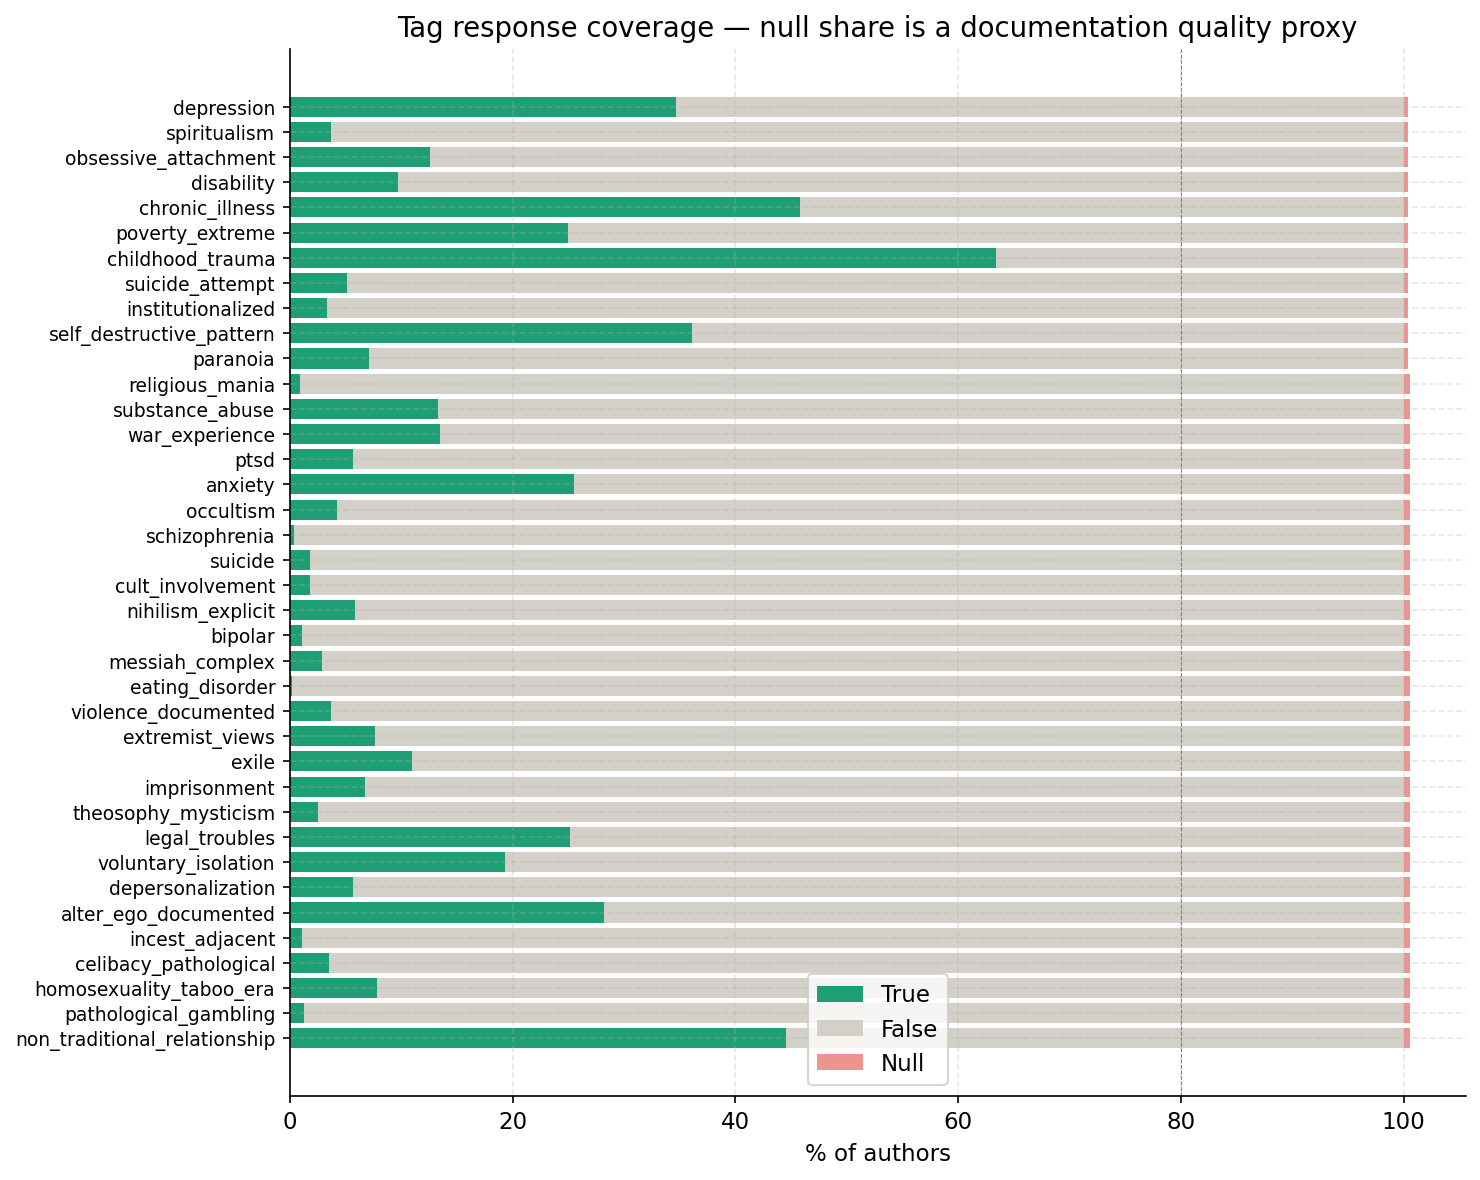

In [3]:
#1.1 Per-tag null / true / false coverage
null_stats = []
for t in TAGS:
    if t not in df.columns: continue
    col = df[t]
    null_stats.append({
        'tag':       TAG_SHORT[t],
        'true_pct':  col.eq(True).mean()  * 100,
        'false_pct': col.eq(False).mean() * 100,
        'null_pct':  col.isna().mean()    * 100,
    })
null_df = pd.DataFrame(null_stats).sort_values('null_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
y = range(len(null_df))
ax.barh(list(y), null_df['true_pct'],  color='#1D9E75', label='True')
ax.barh(list(y), null_df['false_pct'], left=null_df['true_pct'], color='#D3D1C7', label='False')
ax.barh(list(y), null_df['null_pct'],
        left=null_df['true_pct']+null_df['false_pct'],
        color='#E24B4A', alpha=0.6, label='Null')
ax.set_yticks(list(y)); ax.set_yticklabels(null_df['tag'], fontsize=9)
ax.set_xlabel('% of authors')
ax.set_title('Tag response coverage — null share is a documentation quality proxy',
             fontweight='500')
ax.legend(); ax.axvline(80, color='gray', lw=0.5, linestyle='--')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig01_tag_coverage.png', bbox_inches='tight')
plt.show()

# Store per-author null rate for sensitivity analysis
df['null_rate'] = df[TAGS].isna().mean(axis=1)

---
## 2. Baseline Statistics
**FIX: median + IQR as primary; mean as secondary (score = ordinal scale)**

=== Score (ordinal — report median+IQR first) ===
N       : 567
Median  : 5.0
IQR     : [3.0, 6.0]
Mean    : 4.61  (secondary; assumes interval scale)
Std     : 2.27
% ≥ 5   : 50.3%
% ≥ 7   : 23.5%


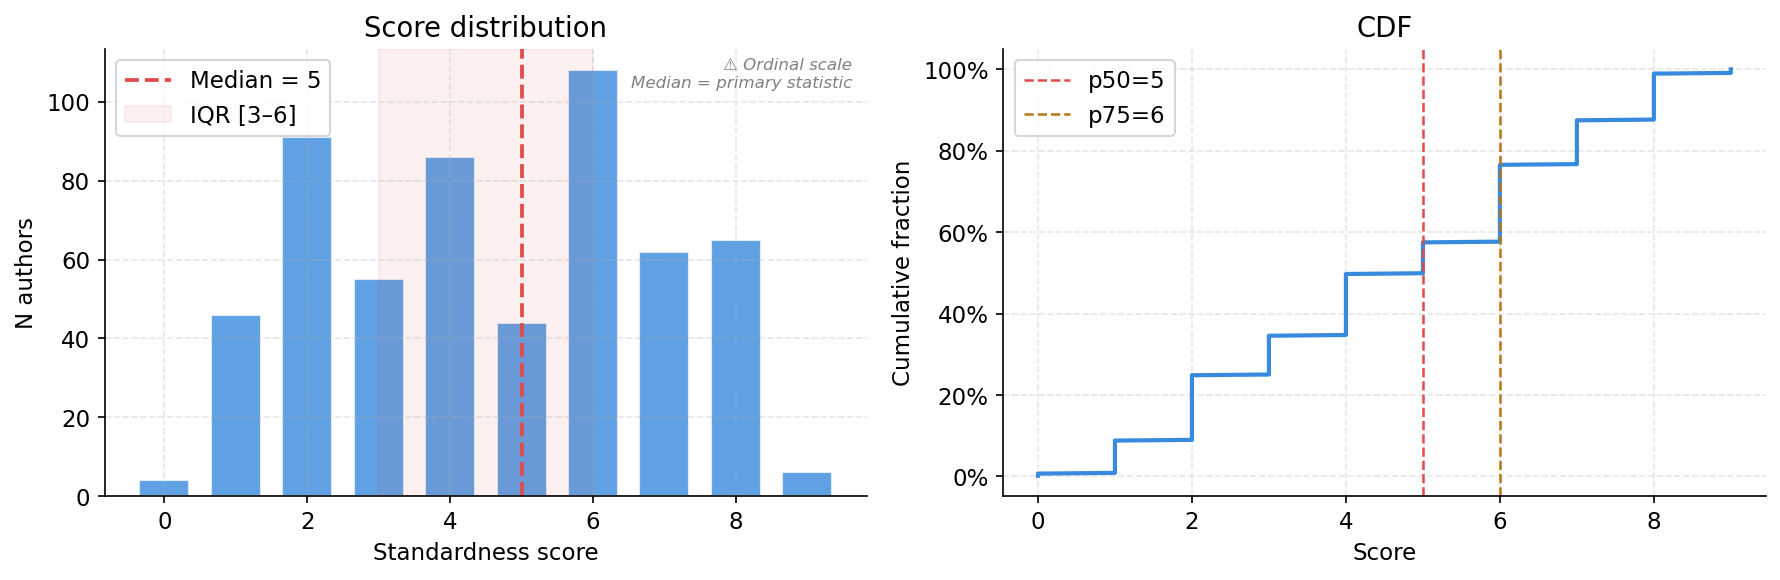

In [4]:
#2.1  Score distribution
s = df['score']
print('=== Score (ordinal — report median+IQR first) ===')
print(f'N       : {s.notna().sum()}')
print(f'Median  : {s.median()}')
print(f'IQR     : [{s.quantile(0.25)}, {s.quantile(0.75)}]')
print(f'Mean    : {s.mean():.2f}  (secondary; assumes interval scale)')
print(f'Std     : {s.std():.2f}')
print(f'% ≥ 5   : {(s>=5).mean()*100:.1f}%')
print(f'% ≥ 7   : {(s>=7).mean()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
sc = s.value_counts().sort_index()
ax.bar(sc.index, sc.values, color='#378ADD', alpha=0.8, width=0.7, edgecolor='white')
ax.axvline(s.median(), color='#E24B4A', lw=1.8, linestyle='--',
           label=f'Median = {s.median():.0f}')
# IQR shading
ax.axvspan(s.quantile(0.25), s.quantile(0.75), alpha=0.08, color='#E24B4A',
           label=f'IQR [{s.quantile(0.25):.0f}–{s.quantile(0.75):.0f}]')
ax.set_xlabel('Standardness score'); ax.set_ylabel('N authors')
ax.set_title('Score distribution', fontweight='500'); ax.legend()
ax.text(0.98, 0.98, '⚠ Ordinal scale\nMedian = primary statistic',
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray',
        style='italic')

ax2 = axes[1]
xs = np.sort(s.dropna())
ax2.plot(xs, np.arange(1, len(xs)+1)/len(xs), color='#378ADD', lw=2)
for pct, col in [(50, '#E24B4A'), (75, '#BA7517')]:
    v = np.percentile(xs, pct)
    ax2.axvline(v, color=col, lw=1.2, linestyle='--', label=f'p{pct}={v:.0f}')
ax2.set_xlabel('Score'); ax2.set_ylabel('Cumulative fraction')
ax2.set_title('CDF', fontweight='500'); ax2.legend()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig02_score_distribution.png', bbox_inches='tight')
plt.show()

---
## 3. Era Analysis
**FIX: Holm–Bonferroni correction on pairwise tests**

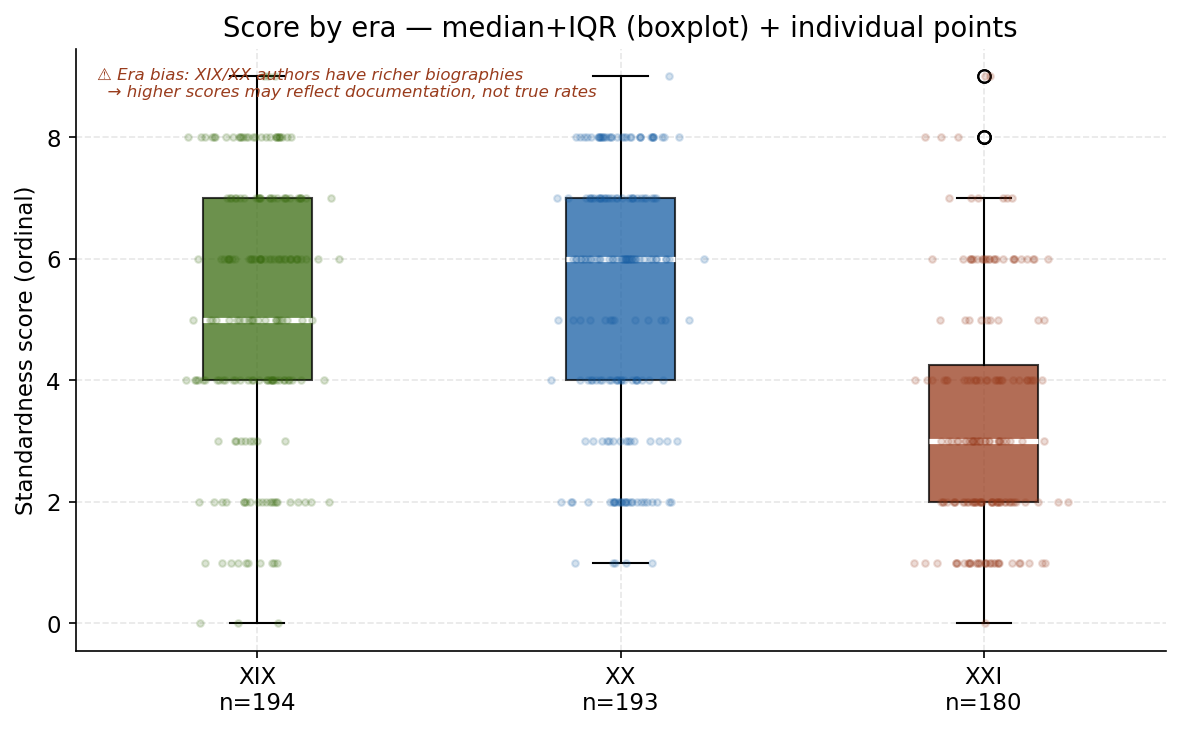

XIX: median=5.0  IQR=[4.0,7.0]  n=194
XX: median=6.0  IQR=[4.0,7.0]  n=193
XXI: median=3.0  IQR=[2.0,4.2]  n=180


In [5]:
#3.1  Boxplot (median+IQR) by era
era_order = ['XIX', 'XX', 'XXI']
era_data  = {e: df[df['era'] == e]['score'].dropna() for e in era_order}
valid_eras = [e for e in era_order if len(era_data[e]) >= 5]

fig, ax = plt.subplots(figsize=(8, 5))
bp_data   = [era_data[e].values for e in valid_eras]
bp_labels = [f'{e}\nn={len(era_data[e])}' for e in valid_eras]
bp = ax.boxplot(bp_data, labels=bp_labels, patch_artist=True, notch=False,
                medianprops=dict(color='white', lw=2.5))
for patch, e in zip(bp['boxes'], valid_eras):
    patch.set_facecolor(ERA_COLORS[e]); patch.set_alpha(0.75)

# Strip plot overlay for n visibility
for i, e in enumerate(valid_eras, 1):
    jitter = np.random.normal(0, 0.08, len(era_data[e]))
    ax.scatter(i + jitter, era_data[e], alpha=0.18, s=10,
               color=ERA_COLORS[e], zorder=3)

ax.set_ylabel('Standardness score (ordinal)')
ax.set_title('Score by era — median+IQR (boxplot) + individual points',
             fontweight='500')
ax.text(0.02, 0.97,
        '⚠ Era bias: XIX/XX authors have richer biographies\n'
        '  → higher scores may reflect documentation, not true rates',
        transform=ax.transAxes, va='top', fontsize=8, color='#993C1D', style='italic')
plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig03_era_boxplot.png', bbox_inches='tight')
plt.show()

for e in valid_eras:
    d = era_data[e]
    print(f'{e}: median={d.median():.1f}  IQR=[{d.quantile(0.25):.1f},{d.quantile(0.75):.1f}]  n={len(d)}')

In [6]:
#Pairwise Mann-Whitney U with Holm correction
print('=== Era pairwise Mann-Whitney U + Holm correction ===')

pairs_era = list(combinations(valid_eras, 2))
raw_p, us, rs = [], [], []
for e1, e2 in pairs_era:
    u, p = mannwhitneyu(era_data[e1], era_data[e2], alternative='two-sided')
    n1, n2 = len(era_data[e1]), len(era_data[e2])
    z = (u - n1*n2/2) / np.sqrt(n1*n2*(n1+n2+1)/12)
    raw_p.append(p); us.append(u); rs.append(abs(z)/np.sqrt(n1+n2))

reject, p_holm, _, _ = multipletests(raw_p, method='holm')

for (e1,e2), u, p_raw, p_h, rej, r in zip(pairs_era, us, raw_p, p_holm, reject, rs):
    sig = '*** (sig)' if p_h < 0.001 else '** (sig)' if p_h < 0.01 else \
          '* (sig)'  if p_h < 0.05  else 'ns'
    print(f'{e1} vs {e2}:  U={u:.0f}  p_raw={p_raw:.4f}  '
          f'p_Holm={p_h:.4f}  r={r:.3f}  {sig}')

print('\nNote: Holm correction applied to all 3 pairwise tests simultaneously.')
print('r interpretation: 0.1=small, 0.3=medium, 0.5=large')

=== Era pairwise Mann-Whitney U + Holm correction ===
XIX vs XX:  U=17646  p_raw=0.3229  p_Holm=0.3229  r=0.050  ns
XIX vs XXI:  U=25168  p_raw=0.0000  p_Holm=0.0000  r=0.382  *** (sig)
XX vs XXI:  U=25852  p_raw=0.0000  p_Holm=0.0000  r=0.422  *** (sig)

Note: Holm correction applied to all 3 pairwise tests simultaneously.
r interpretation: 0.1=small, 0.3=medium, 0.5=large


---
## 4. Gender Analysis
**FIX: Unknown-rate audit + Western-only sensitivity + limitation note**

In [7]:
#4.1 Assign gender with explicit Unknown audit
try:
    import gender_guesser.detector as gender_lib
    d_gen = gender_lib.Detector()
    def guess_gender(name):
        first = str(name).split()[0] if isinstance(name, str) else ''
        g = d_gen.get_gender(first)
        if g in ('male','mostly_male'):     return 'M'
        if g in ('female','mostly_female'): return 'F'
        return 'Unknown'
    if 'gender' not in df.columns:
        df['gender'] = df['author_name'].apply(guess_gender)
except ImportError:
    print('gender-guesser not installed → all Unknown.')
    df['gender'] = 'Unknown'

print('=== Gender distribution ===')
print(df['gender'].value_counts())
unk_pct = (df['gender'] == 'Unknown').mean() * 100
print(f'\nUnknown rate: {unk_pct:.1f}%')
print()
# LIMITATION FLAG
if unk_pct > 20:
    print('  LIMITATION: gender-guesser is trained on Western names.')
    print('  Non-Western authors (Japanese, Arabic, Russian, Chinese) are')
    print('  disproportionately Unknown → gender analysis is biased toward')
    print('  Western authors. Report this explicitly in the paper.')
    print()

# Show which names are Unknown (to assess bias direction)
unk_authors = df[df['gender']=='Unknown'][['author_name','era']].head(20)
print('Sample of Unknown-gender authors:')
print(unk_authors.to_string(index=False))

=== Gender distribution ===
gender
M          365
F          175
Unknown     27
Name: count, dtype: int64

Unknown rate: 4.8%

Sample of Unknown-gender authors:
                       author_name era
            Ernest Lawrence Thayer XIX
Auguste de Villiers de l'Isle-Adam XIX
                             Pansy XIX
                     Charles Gould XIX
                     John G. Paton XIX
                        James Otis XIX
                 Γεώργιος Βιζυηνός XIX
             Frederick Winkel Horn XIX
                             Tasma XIX
                    James B. Marsh XIX
                       John Nelson XIX
                      George Moore XIX
                    Henry Drummond XIX
                       Tim O'Brien  XX
                    Richard Wright  XX
                         Dee Brown  XX
                   David  Mitchell XXI
                       Erik Larson XXI
                 Christopher Moore XXI
                  Geraldine Brooks XXI


In [8]:
#4.2Score by gender — full + Western-only sensitivity
def gender_score_test(data, label=''):
    """Print M vs F score comparison with Mann-Whitney U."""
    gm = data[data['gender']=='M']['score'].dropna()
    gf = data[data['gender']=='F']['score'].dropna()
    if len(gm) < 5 or len(gf) < 5:
        print(f'{label}: not enough data (M={len(gm)}, F={len(gf)})')
        return
    u, p = mannwhitneyu(gm, gf, alternative='two-sided')
    print(f'{label}')
    print(f'  M: median={gm.median():.1f} IQR=[{gm.quantile(.25):.1f},{gm.quantile(.75):.1f}] n={len(gm)}')
    print(f'  F: median={gf.median():.1f} IQR=[{gf.quantile(.25):.1f},{gf.quantile(.75):.1f}] n={len(gf)}')
    print(f'  U={u:.0f}  p={p:.4f}  sig={"*" if p<0.05 else "ns"}')

# Full sample
gender_score_test(df, 'All authors (including Unknown-gender)')
print()
# Western-only sensitivity: exclude clearly non-Western names
# Proxy: authors where gender-guesser gave M or F (i.e. Western-looking first name)
df_western = df[df['gender'].isin(['M','F'])]
gender_score_test(df_western, 'Western-name authors only (gender-guesser resolved)')
print()
print('If results differ significantly between the two runs,')
print('the gender finding is driven by Western-author composition, not true gender effect.')

All authors (including Unknown-gender)
  M: median=5.0 IQR=[3.0,7.0] n=365
  F: median=4.0 IQR=[2.0,6.0] n=175
  U=39499  p=0.0000  sig=*

Western-name authors only (gender-guesser resolved)
  M: median=5.0 IQR=[3.0,7.0] n=365
  F: median=4.0 IQR=[2.0,6.0] n=175
  U=39499  p=0.0000  sig=*

If results differ significantly between the two runs,
the gender finding is driven by Western-author composition, not true gender effect.


=== Tag prevalence M vs F (Western-name authors; Holm-corrected) ===
                         tag  M_pct  F_pct  diff_MF  p_raw  p_Holm sig
                    paranoia   8.49   3.43     5.06   0.03    0.57  ns
        obsessive_attachment  15.07   8.57     6.50   0.04    0.64  ns
             extremist_views   9.59   2.86     6.73   0.00    0.10  ns
                imprisonment   9.32   2.29     7.03   0.00    0.05   *
           nihilism_explicit   8.49   1.14     7.35   0.00    0.01   *
             poverty_extreme  27.67  18.86     8.81   0.03    0.59  ns
non_traditional_relationship  48.49  39.43     9.06   0.05    0.79  ns
                  depression  38.63  29.14     9.49   0.03    0.59  ns
                       exile  14.52   4.57     9.95   0.00    0.01   *
            childhood_trauma  68.22  57.71    10.50   0.02    0.44  ns
         voluntary_isolation  23.29  12.00    11.29   0.00    0.04   *
             chronic_illness  50.41  38.86    11.55   0.01    0.28  ns
        

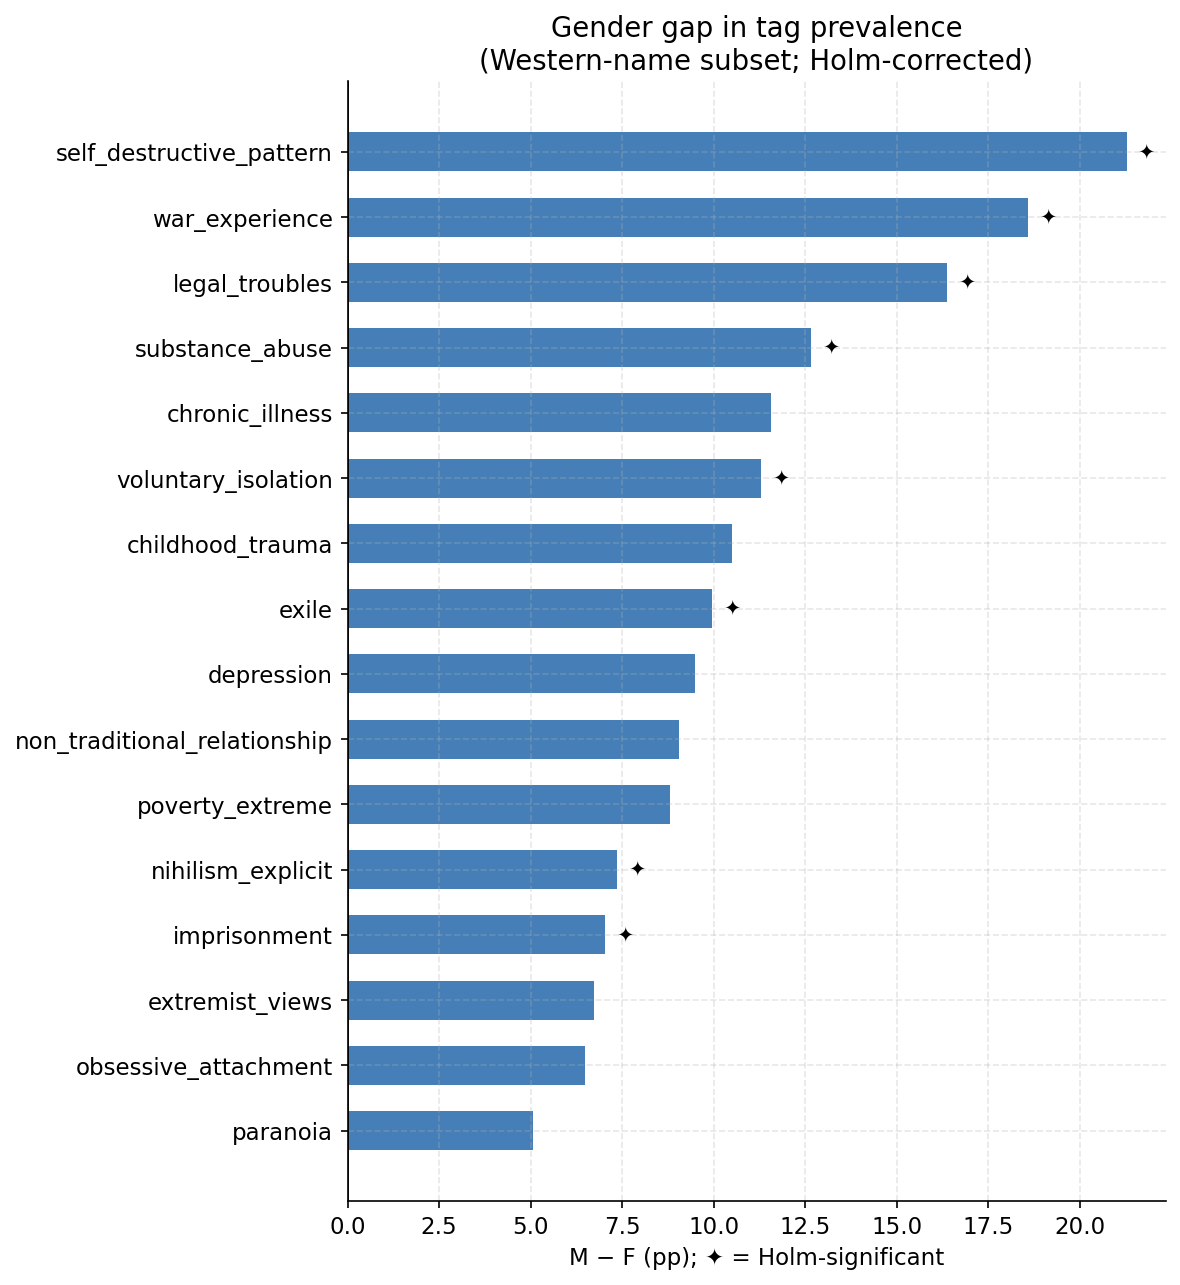

In [9]:
#4.3 Tag prevalence by gender — Holm-corrected
# Run on Western-name subset for validity
print('Tag prevalence M vs F (Western-name authors; Holm-corrected)')

sub_gen = df[df['gender'].isin(['M','F'])]
gm_df = sub_gen[sub_gen['gender']=='M']
gf_df = sub_gen[sub_gen['gender']=='F']

tag_gender_rows = []
for t in TAGS:
    if t not in df.columns: continue
    sub_t = sub_gen[sub_gen[t].notna()]
    gm_t  = sub_t[sub_t['gender']=='M'][t].eq(True)
    gf_t  = sub_t[sub_t['gender']=='F'][t].eq(True)
    if gm_t.sum() + gf_t.sum() < 10: continue
    ct = pd.crosstab(sub_t['gender'], sub_t[t].eq(True))
    if ct.shape == (2,2):
        _, p = fisher_exact(ct)
        tag_gender_rows.append({
            'tag':     TAG_SHORT[t],
            'M_pct':   gm_t.mean()*100,
            'F_pct':   gf_t.mean()*100,
            'diff_MF': gm_t.mean()*100 - gf_t.mean()*100,
            'p_raw':   p,
            'n_M':     len(gm_t), 'n_F': len(gf_t),
        })

tg_df = pd.DataFrame(tag_gender_rows)
if len(tg_df) > 0:
    reject, p_holm, _, _ = multipletests(tg_df['p_raw'], method='holm')
    tg_df['p_Holm'] = p_holm
    tg_df['sig']    = ['*' if p<0.05 else 'ns' for p in p_holm]
    tg_df = tg_df.sort_values('diff_MF')

    # Show only tags with |diff| >= 5pp OR Holm-significant
    notable = tg_df[(tg_df['diff_MF'].abs() >= 5) | (tg_df['sig']=='*')]
    if len(notable) == 0:
        print('⚠ No notable gender tag gaps (|diff| < 5pp and no Holm-significant tags).')
        print('Showing top-10 by absolute difference instead:')
        notable = tg_df.nlargest(10, 'diff_MF').append(
            tg_df.nsmallest(10, 'diff_MF')).drop_duplicates()
    print(notable[['tag','M_pct','F_pct','diff_MF','p_raw','p_Holm','sig']]
          .round(2).to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, len(notable)*0.45+1.5))
    cols = ['#185FA5' if v>0 else '#993556' for v in notable['diff_MF']]
    bars = ax.barh(notable['tag'], notable['diff_MF'], color=cols, height=0.6, alpha=0.8)
    # Star on Holm-significant
    for bar, sig in zip(bars, notable['sig']):
        if sig == '*':
            ax.text(bar.get_width() + 0.3 if bar.get_width()>0 else bar.get_width()-0.3,
                    bar.get_y()+bar.get_height()/2, '✦', va='center', fontsize=10)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('M − F (pp); ✦ = Holm-significant')
    ax.set_title('Gender gap in tag prevalence\n(Western-name subset; Holm-corrected)',
                 fontweight='500')
    plt.tight_layout()
    plt.savefig(FIGS_DIR/'fig04_gender_tag_gap.png', bbox_inches='tight')
    print('fig04 saved.')
    plt.show()

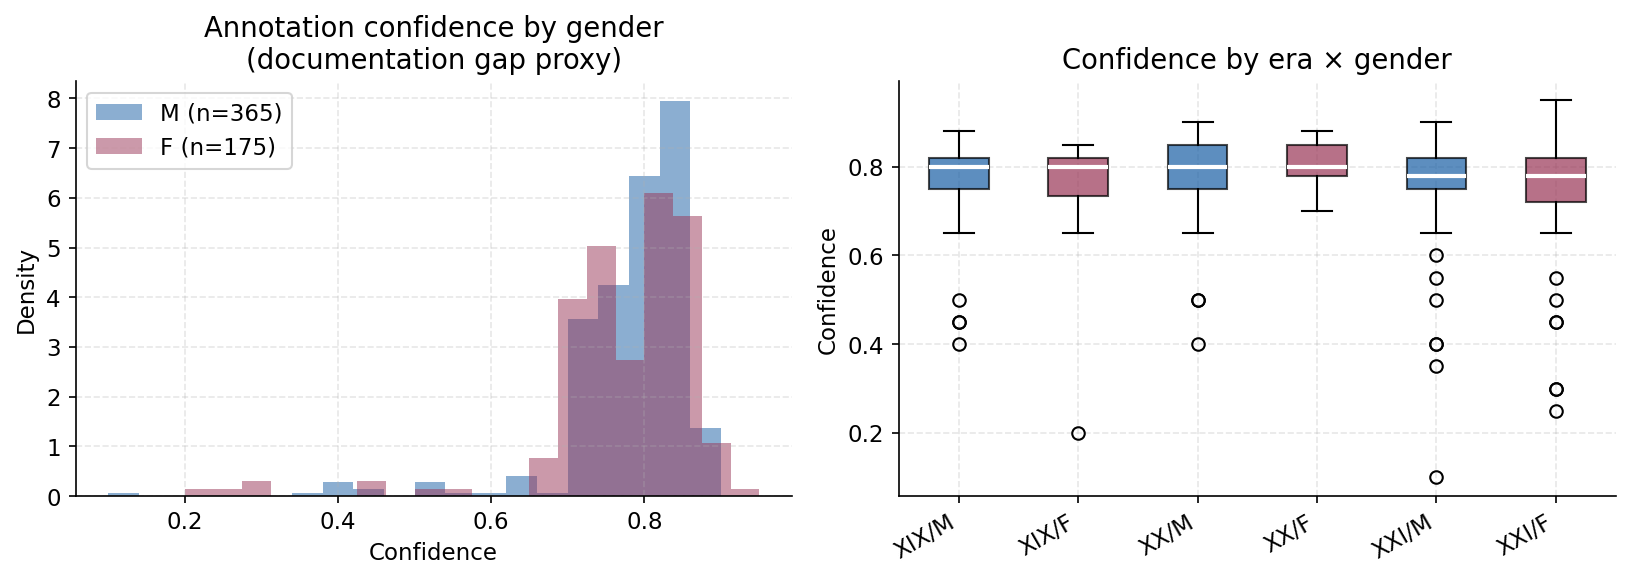

In [10]:
#4.4 Documentation gap: confidence by gender
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram
ax = axes[0]
for g, col in [('M','#185FA5'), ('F','#993556')]:
    c = df[df['gender']==g]['conf'].dropna()
    ax.hist(c, bins=20, alpha=0.5, density=True, label=f'{g} (n={len(c)})', color=col)
ax.set_xlabel('Confidence'); ax.set_ylabel('Density')
ax.set_title('Annotation confidence by gender\n(documentation gap proxy)', fontweight='500')
ax.legend()

# Boxplot per gender × era
ax2 = axes[1]
plot_data, plot_labels, plot_colors = [], [], []
for e in valid_eras:
    for g, col in [('M','#185FA5'),('F','#993556')]:
        sub = df[(df['era']==e)&(df['gender']==g)]['conf'].dropna()
        if len(sub) >= 5:
            plot_data.append(sub.values)
            plot_labels.append(f'{e}/{g}')
            plot_colors.append(col)

if plot_data:
    # tick_labels= is the current param name; labels= is deprecated in mpl >= 3.9
    try:
        bp2 = ax2.boxplot(plot_data, tick_labels=plot_labels, patch_artist=True,
                          medianprops=dict(color='white', lw=2))
    except TypeError:
        # Fallback for older matplotlib that only knows labels=
        bp2 = ax2.boxplot(plot_data, labels=plot_labels, patch_artist=True,
                          medianprops=dict(color='white', lw=2))
    for patch, col in zip(bp2['boxes'], plot_colors):
        patch.set_facecolor(col); patch.set_alpha(0.7)
    ax2.set_ylabel('Confidence')
    ax2.set_title('Confidence by era × gender', fontweight='500')
    plt.xticks(rotation=30, ha='right')
else:
    ax2.text(0.5, 0.5, 'Not enough data\nper era/gender cell',
             ha='center', va='center', transform=ax2.transAxes, color='gray')
    ax2.set_title('Confidence by era × gender', fontweight='500')

plt.tight_layout()
plt.savefig(FIGS_DIR/'fig05_gender_confidence.png', bbox_inches='tight')
plt.show()


---
## 5. Tag Co-occurrence
**FIX: Null-masked Jaccard — only rows where BOTH tags are non-null**

In [11]:
#5.1 Null-masked Jaccard
valid_tags = [t for t in TAGS if t in df.columns]
short_names = [TAG_SHORT[t] for t in valid_tags]
n_tags = len(valid_tags)

jaccard = pd.DataFrame(np.zeros((n_tags, n_tags)),
                        index=short_names, columns=short_names)
both_counts = pd.DataFrame(np.zeros((n_tags, n_tags), dtype=int),
                            index=short_names, columns=short_names)

for i, (t1, s1) in enumerate(zip(valid_tags, short_names)):
    for j, (t2, s2) in enumerate(zip(valid_tags, short_names)):
        if i >= j: continue
        # Mask: both non-null
        mask = df[t1].notna() & df[t2].notna()
        sub1 = df.loc[mask, t1].eq(True)
        sub2 = df.loc[mask, t2].eq(True)
        both  = (sub1 & sub2).sum()
        either = (sub1 | sub2).sum()
        j_val = both / either if either > 0 else 0.0
        jaccard.loc[s1, s2] = j_val
        jaccard.loc[s2, s1] = j_val
        both_counts.loc[s1, s2] = both
        both_counts.loc[s2, s1] = both

np.fill_diagonal(jaccard.values, 1.0)
print('Null-masked Jaccard matrix computed.')
print(f'Example: depression ↔ substance_abuse = '
      f'{jaccard.loc["depression","substance_abuse"]:.3f}')

Null-masked Jaccard matrix computed.
Example: depression ↔ substance_abuse = 0.216


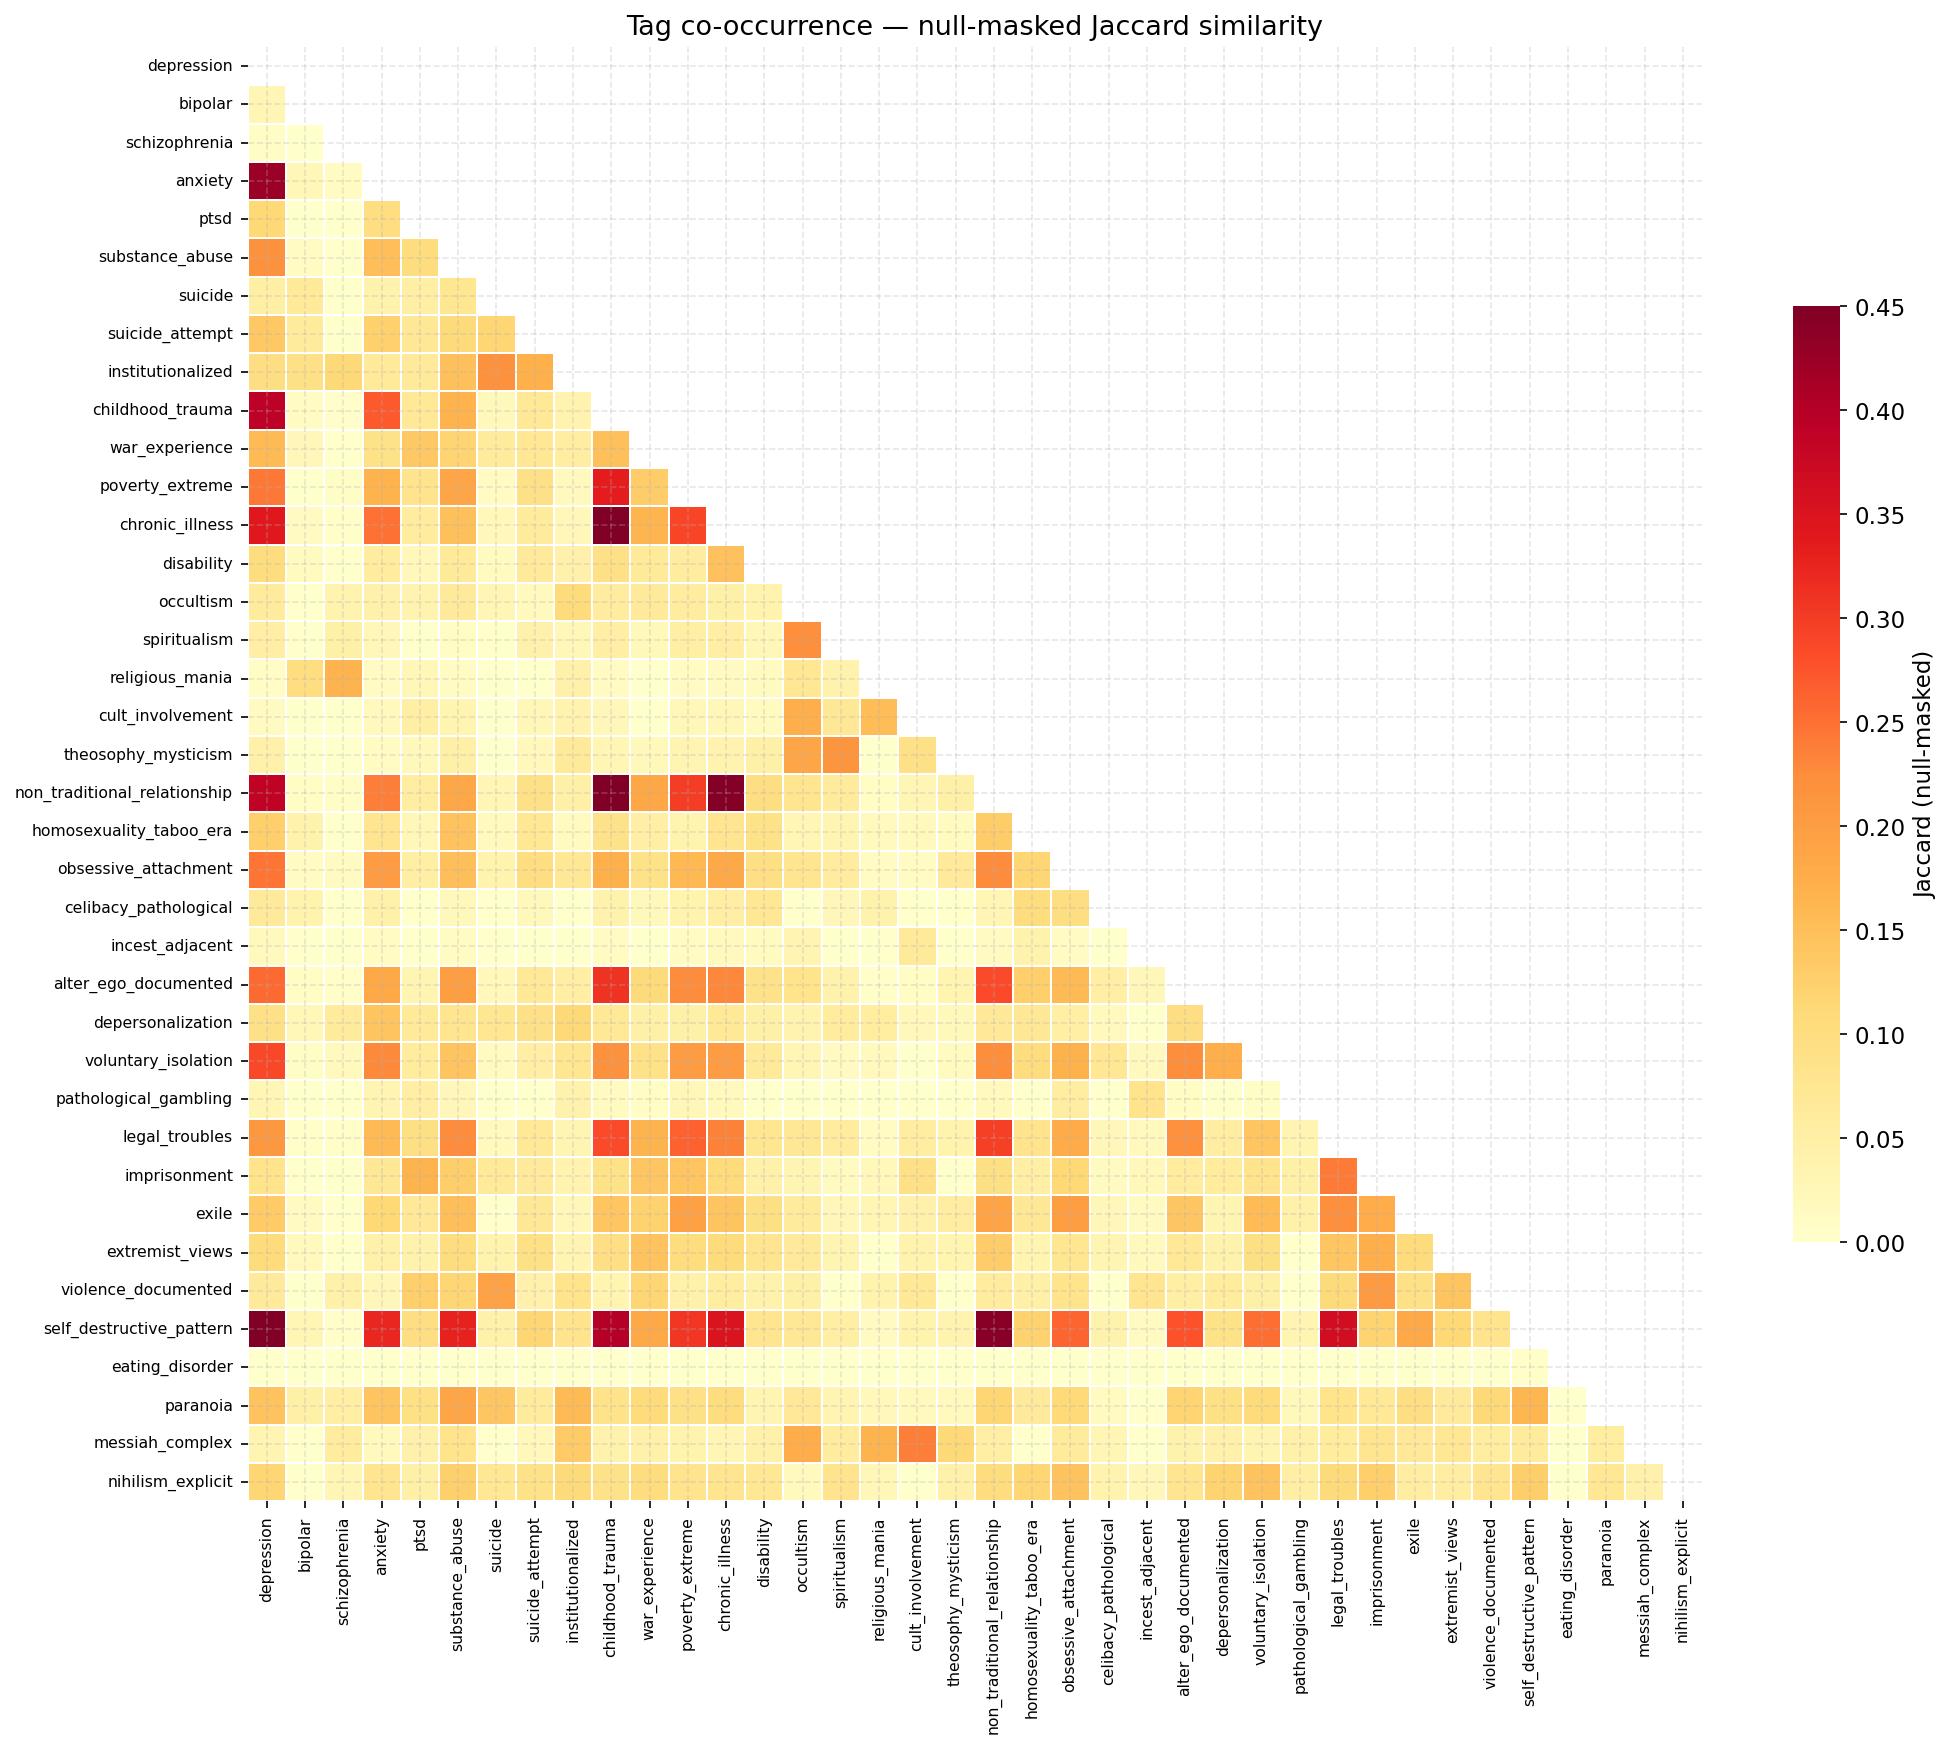

In [12]:
#5.2 Full 38×38 heatmap
mask_tri = np.triu(np.ones_like(jaccard, dtype=bool))
fig, ax  = plt.subplots(figsize=(14, 12))
sns.heatmap(jaccard, mask=mask_tri, cmap='YlOrRd', vmin=0, vmax=0.45,
            square=True, linewidths=0.2, linecolor='white',
            cbar_kws={'shrink':0.6,'label':'Jaccard (null-masked)'},
            ax=ax, annot=False)
ax.set_title('Tag co-occurrence — null-masked Jaccard similarity', fontweight='500', fontsize=13)
ax.tick_params(axis='x', rotation=90, labelsize=7.5)
ax.tick_params(axis='y', rotation=0,  labelsize=7.5)
plt.tight_layout()
plt.savefig(FIGS_DIR/'fig06_cooccurrence_heatmap.png', bbox_inches='tight', dpi=200)
plt.show()

In [13]:
#5.3 Top pairs + lift
pairs_list = []
for s1, s2 in combinations(short_names, 2):
    t1 = 'tag_' + s1; t2 = 'tag_' + s2
    if t1 not in df.columns or t2 not in df.columns: continue
    mask = df[t1].notna() & df[t2].notna()
    n_obs = mask.sum()
    if n_obs < 20: continue
    p1 = df.loc[mask, t1].eq(True).mean()
    p2 = df.loc[mask, t2].eq(True).mean()
    j  = jaccard.loc[s1, s2]
    # Lift = P(A∩B) / (P(A)×P(B)) — values >> 1 mean co-occur more than chance
    p_both = df.loc[mask, t1].eq(True).values & df.loc[mask, t2].eq(True).values
    lift   = p_both.mean() / (p1 * p2 + 1e-9) if p1 * p2 > 0 else np.nan
    pairs_list.append({'tag_a':s1,'tag_b':s2,'jaccard':j,'lift':lift,
                       'n_both':int(both_counts.loc[s1,s2]),'n_obs':n_obs})

pairs_df = pd.DataFrame(pairs_list).sort_values('jaccard', ascending=False)
print('Top 20 co-occurring pairs (null-masked):')
print(pairs_df.head(20)[['tag_a','tag_b','jaccard','lift','n_both']]
      .round(3).to_string(index=False))

Top 20 co-occurring pairs (null-masked):
                       tag_a                        tag_b  jaccard  lift  n_both
            childhood_trauma              chronic_illness    0.498 1.249     205
            childhood_trauma non_traditional_relationship    0.498 1.271     202
                  depression     self_destructive_pattern    0.455 1.766     125
             chronic_illness non_traditional_relationship    0.446 1.367     157
non_traditional_relationship     self_destructive_pattern    0.441 1.539     139
                  depression                      anxiety    0.424 2.029     101
            childhood_trauma     self_destructive_pattern    0.401 1.246     161
                  depression             childhood_trauma    0.392 1.256     156
                  depression non_traditional_relationship    0.389 1.440     125
              legal_troubles     self_destructive_pattern    0.364 1.800      92
             chronic_illness     self_destructive_pattern    0.350 1

---
## 6. Temporal Trends

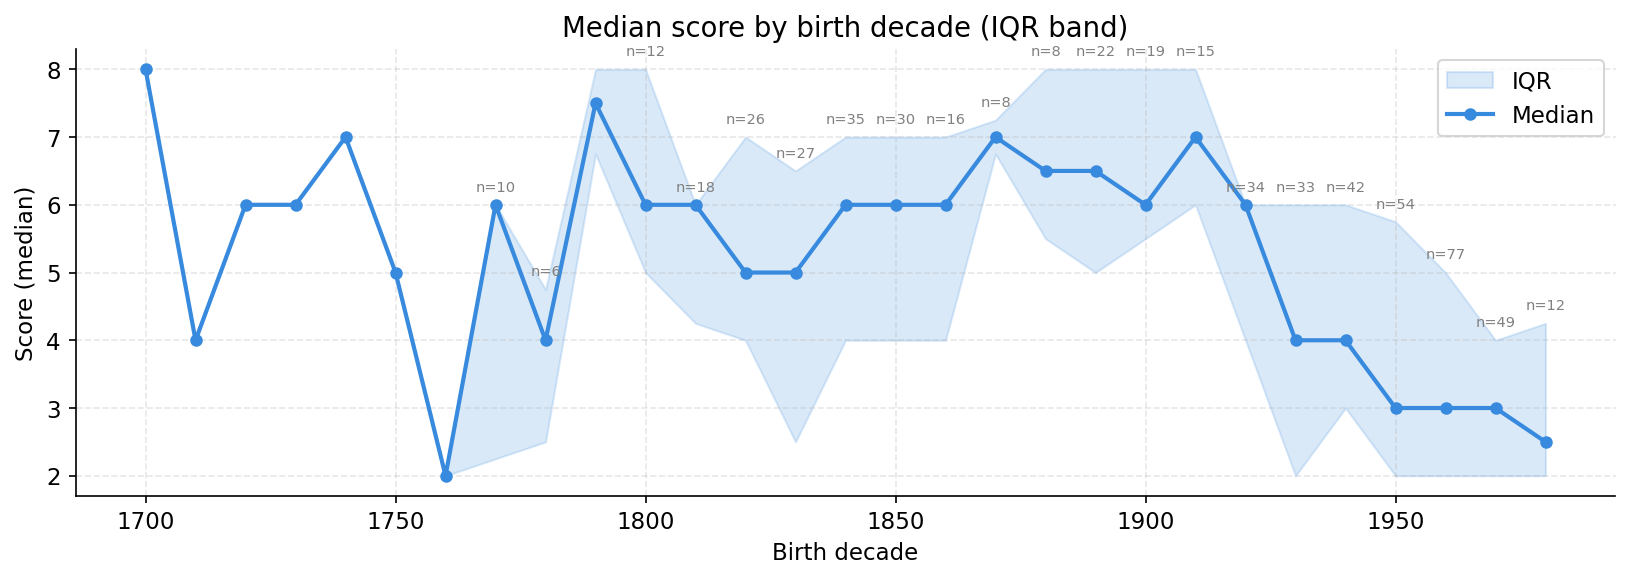

In [14]:
#6.1 Median score by decade
decade_df = df[df['decade'].notna()].copy()
dec_stats = decade_df.groupby('decade')['score'].agg(
    median='median', q25=lambda x: x.quantile(.25),
    q75=lambda x: x.quantile(.75), count='count'
).reset_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(dec_stats['decade'], dec_stats['q25'], dec_stats['q75'],
                alpha=0.18, color='#378ADD', label='IQR')
ax.plot(dec_stats['decade'], dec_stats['median'],
        'o-', color='#378ADD', lw=2, ms=5, label='Median')
for _, row in dec_stats.iterrows():
    if row['count'] >= 5:
        ax.annotate(f'n={int(row["count"])}',
                    (row['decade'], row['q75']+0.2), fontsize=7, ha='center', color='gray')
ax.set_xlabel('Birth decade'); ax.set_ylabel('Score (median)')
ax.set_title('Median score by birth decade (IQR band)', fontweight='500')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS_DIR/'fig07_score_by_decade.png', bbox_inches='tight')
plt.show()

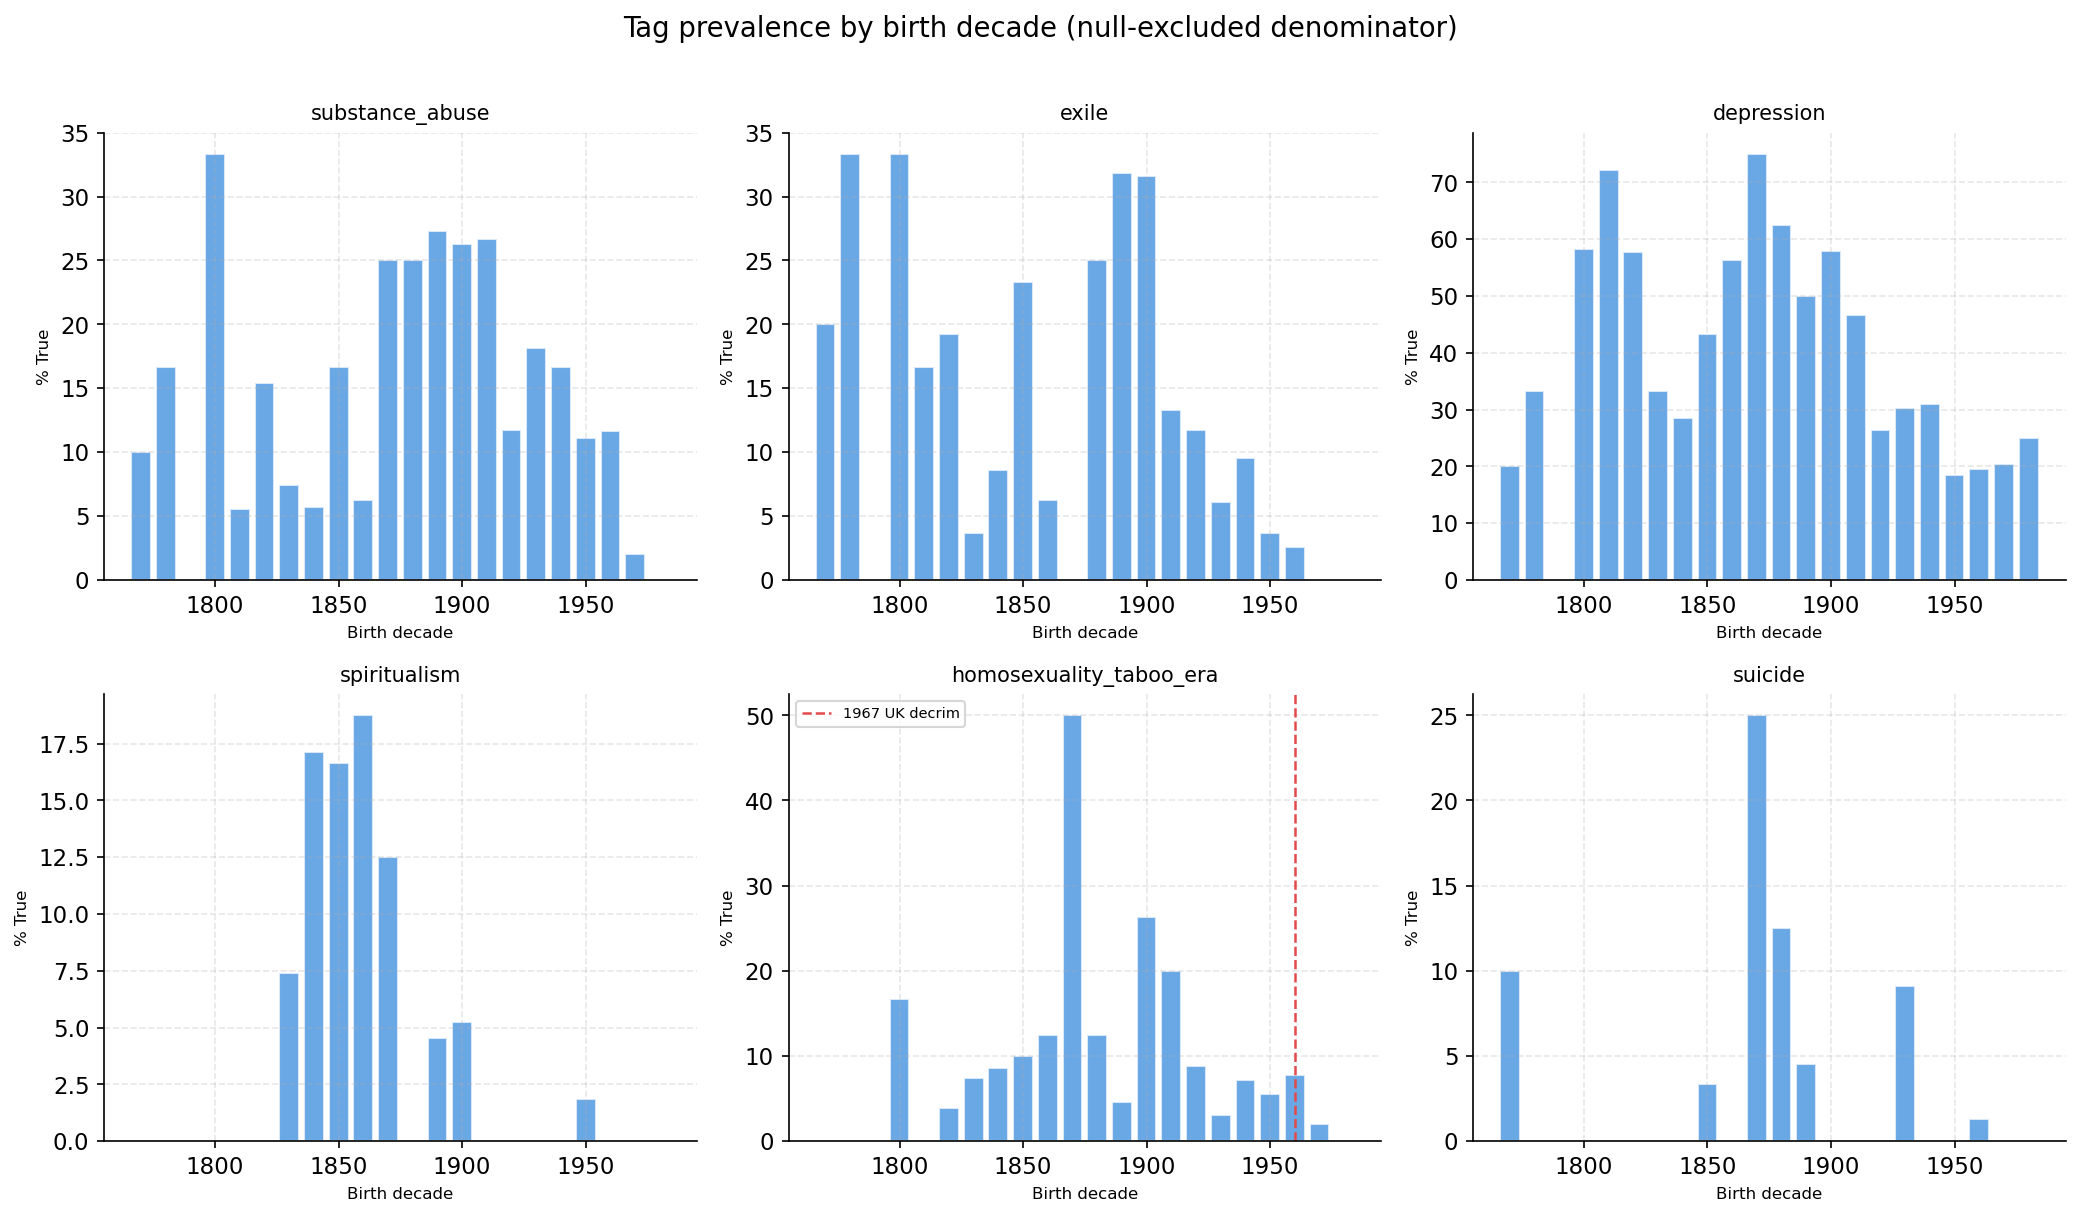

In [15]:
#6.2 Focal tags over decades
FOCAL = ['tag_substance_abuse','tag_exile','tag_depression',
         'tag_spiritualism','tag_homosexuality_taboo_era','tag_suicide']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, tag in enumerate(FOCAL):
    if tag not in df.columns: continue
    ax = axes[i]
    # Only rows where tag is non-null
    sub = decade_df[decade_df[tag].notna()]
    rates = sub.groupby('decade')[tag].apply(
        lambda x: x.eq(True).sum() / len(x) * 100)
    ns    = sub.groupby('decade')[tag].count()
    rates = rates[ns >= 5]
    ax.bar(rates.index, rates.values, width=8, color='#378ADD', alpha=0.75, edgecolor='white')
    ax.set_title(TAG_SHORT[tag], fontweight='500', fontsize=10)
    ax.set_xlabel('Birth decade', fontsize=8); ax.set_ylabel('% True', fontsize=8)
    if tag == 'tag_homosexuality_taboo_era':
        ax.axvline(1960, color='#E24B4A', lw=1.2, linestyle='--', label='1967 UK decrim')
        ax.legend(fontsize=7)

plt.suptitle('Tag prevalence by birth decade (null-excluded denominator)',
             fontweight='500', y=1.01)
plt.tight_layout()
plt.savefig(FIGS_DIR/'fig08_temporal_tags.png', bbox_inches='tight')
plt.show()

---
## 7. Goodreads Correlations
**FIX: Partial Spearman controlling for era; Holm correction on 38-tag regression**

In [16]:
#7.1 Partial Spearman: score vs ratings_count controlling for era
# Partial rank correlation: residualize both variables on era_int,
# then correlate residuals.

from scipy.stats import rankdata

def partial_spearman(x_col, y_col, cov_col, data):
    sub = data[[x_col, y_col, cov_col]].dropna()
    if len(sub) < 20: return np.nan, np.nan, len(sub)
    # Rank all three
    rx = rankdata(sub[x_col])
    ry = rankdata(sub[y_col])
    rc = rankdata(sub[cov_col])
    # Residualize
    def resid_on(a, b):
        b_ = b - b.mean(); a_ = a - a.mean()
        beta = np.dot(b_, a_) / np.dot(b_, b_) if np.dot(b_,b_)!=0 else 0
        return a_ - beta * b_
    rx_res = resid_on(rx, rc)
    ry_res = resid_on(ry, rc)
    r, p = stats.pearsonr(rx_res, ry_res)  # pearson on residuals ≈ partial rank corr
    return r, p, len(sub)

print('Partial Spearman (controlling for era)')
for xcol, xlbl in [('ratings_count','ratings_count'),('avg_rating','avg_rating')]:
    if xcol not in df.columns: continue
    sub = df.copy()
    if xcol == 'ratings_count':
        sub['x_use'] = np.log10(sub[xcol]+1)
    else:
        sub['x_use'] = sub[xcol]
    # Naive Spearman
    s_naive = sub[['x_use','score']].dropna()
    r_naive, p_naive = spearmanr(s_naive['x_use'], s_naive['score'])
    # Partial
    r_part, p_part, n_part = partial_spearman('x_use','score','era_int', sub)
    print(f'{xlbl}:')
    print(f'  Naive Spearman:   r={r_naive:.3f}  p={p_naive:.4f}')
    print(f'  Partial (era):    r={r_part:.3f}  p={p_part:.4f}  n={n_part}')
    delta = abs(r_naive) - abs(r_part)
    if delta > 0.05:
        print(f'  ⚠ Era confound reduces |r| by {delta:.3f} — report partial correlation.')
    print()

=== Partial Spearman (controlling for era) ===
ratings_count:
  Naive Spearman:   r=-0.068  p=0.1056
  Partial (era):    r=0.127  p=0.0024  n=566

avg_rating:
  Naive Spearman:   r=-0.012  p=0.7751
  Partial (era):    r=0.061  p=0.1470  n=567



Holm-significant tags (out of 36 tested):
            tag  log2_ratio  p_raw  p_Holm
chronic_illness      -1.174    0.0   0.003


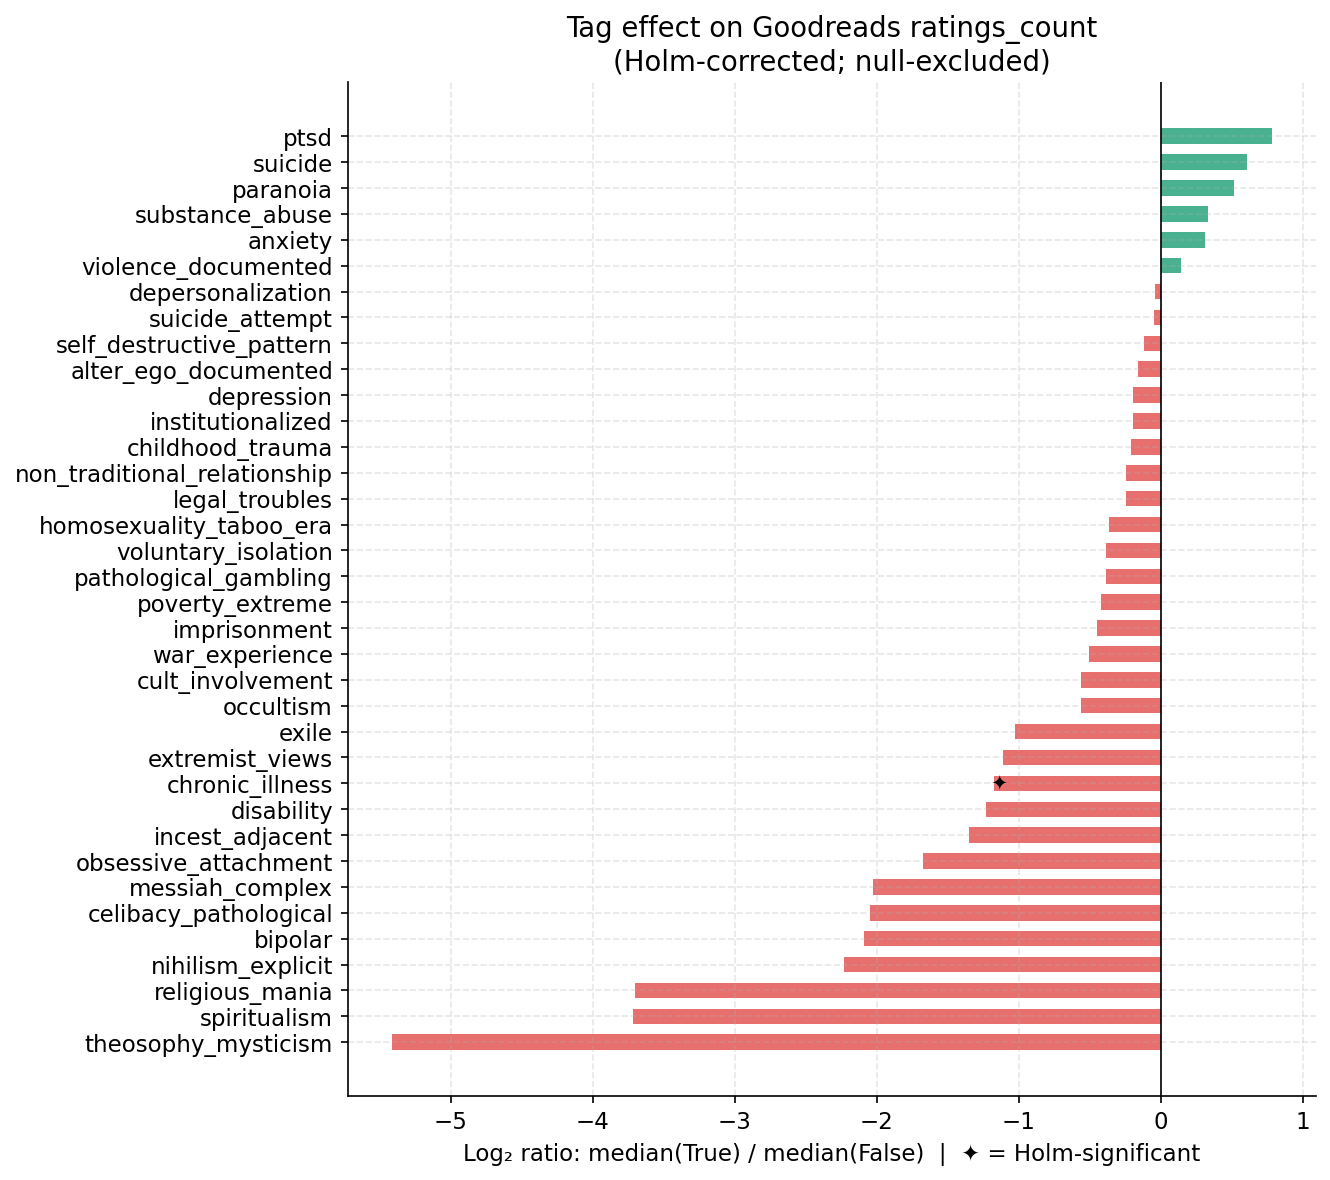

In [17]:
#7.2 Per-tag effect on ratings_count — Holm-corrected
if 'ratings_count' in df.columns:
    tag_rc_rows = []
    for t in TAGS:
        if t not in df.columns: continue
        # Only non-null for BOTH tag and ratings_count
        sub = df[df[t].notna() & df['ratings_count'].notna()]
        tv = sub[sub[t]==True]['ratings_count'].values
        fv = sub[sub[t]==False]['ratings_count'].values
        if len(tv)<5 or len(fv)<5: continue
        _, p = mannwhitneyu(tv, fv, alternative='two-sided')
        ratio = np.median(tv)/np.median(fv) if np.median(fv)>0 else np.nan
        tag_rc_rows.append({'tag':TAG_SHORT[t],'log2_ratio':np.log2(ratio),
                            'p_raw':p,'n_true':len(tv),'n_false':len(fv)})

    rc_df = pd.DataFrame(tag_rc_rows).dropna()
    reject_rc, p_holm_rc, _, _ = multipletests(rc_df['p_raw'], method='holm')
    rc_df['p_Holm'] = p_holm_rc
    rc_df['sig']    = ['✦' if p<0.05 else '' for p in p_holm_rc]
    rc_df = rc_df.sort_values('log2_ratio')

    print(f'Holm-significant tags (out of {len(rc_df)} tested):')
    print(rc_df[rc_df['sig']=='✦'][['tag','log2_ratio','p_raw','p_Holm']]
          .round(3).to_string(index=False))

    fig, ax = plt.subplots(figsize=(9, 8))
    colors = ['#1D9E75' if v>0 else '#E24B4A' for v in rc_df['log2_ratio']]
    bars = ax.barh(rc_df['tag'], rc_df['log2_ratio'], color=colors, height=0.6, alpha=0.8)
    for bar, sig, tag in zip(bars, rc_df['sig'], rc_df['tag']):
        if sig:
            x = bar.get_width()
            ax.text(x + 0.03 if x>0 else x - 0.03, bar.get_y()+bar.get_height()/2,
                    '✦', va='center', fontsize=10)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Log₂ ratio: median(True) / median(False)  |  ✦ = Holm-significant')
    ax.set_title('Tag effect on Goodreads ratings_count\n(Holm-corrected; null-excluded)',
                 fontweight='500')
    plt.tight_layout()
    plt.savefig(FIGS_DIR/'fig09_tag_ratings_effect.png', bbox_inches='tight')
    plt.show()

---
## 8. Clustering — K-modes
**FIX: K-means on binary data is mathematically wrong (Euclidean ≠ Hamming).**  
**K-modes uses Hamming distance — correct for categorical/binary features.**

In [18]:
#8.1 Why K-means was wrong
# Euclidean distance on binary vectors:
#   dist((1,0,0,0), (0,1,0,0)) = sqrt(2)  — two DIFFERENT tags
#   dist((0,0,0,0), (0,0,1,1)) = sqrt(2)  — two same tags but different pair
# The distances are equal but the profiles are psychologically different.
# StandardScaler compounds this: rare tags (2% prevalence) get scaled to the
# same variance as common tags (40% prevalence), inflating their weight.
#
# K-modes:
#   - Cluster center = MODE (most common binary value per feature)
#   - Distance = Hamming (count of differing bits) — correct for binary data
#   - No scaling needed or desirable

try:
    from kmodes.kmodes import KModes
    KMODES_AVAILABLE = True
    print('kmodes available — will use K-modes clustering (correct for binary data).')
except ImportError:
    KMODES_AVAILABLE = False
    print('⚠ kmodes not installed.')
    print('  Install with: pip install kmodes')
    print('  Falling back to hierarchical clustering with average linkage (Hamming).')
    print('  Results are valid but K-modes is preferred for binary data.')

kmodes available — will use K-modes clustering (correct for binary data).


In [19]:
cluster_tags = [t for t in valid_tags if df[t].eq(True).sum() >= 10]
X_bin = df[cluster_tags].eq(True).fillna(False).astype(int)
print(f'Feature matrix: {X_bin.shape}  ({X_bin.shape[1]} tags)')
print('Null → 0 (conservative). This is an assumption — check sensitivity in §10.')

Feature matrix: (567, 32)  (32 tags)
Null → 0 (conservative). This is an assumption — check sensitivity in §10.


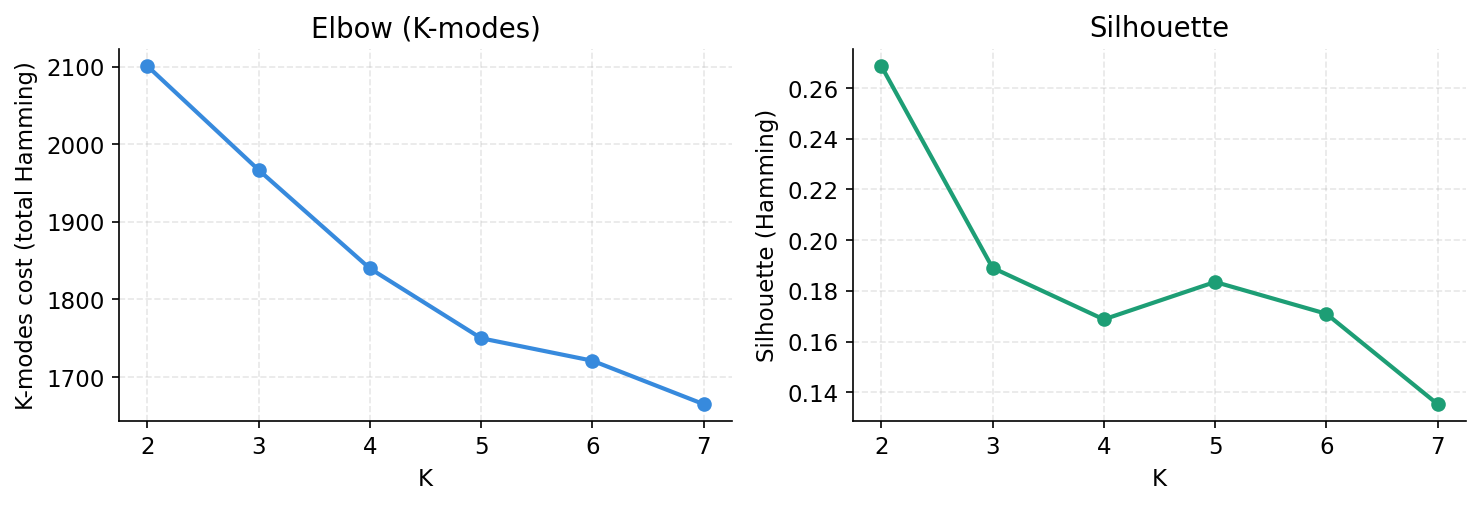

Best K by silhouette (Hamming): 2
Silhouette scores: [0.269, 0.189, 0.169, 0.184, 0.171, 0.135]


In [20]:
#8.3 K selection via silhouette (Hamming)
from sklearn.metrics import silhouette_score

K_range = range(2, 8)
sils_km = []

# Pre-compute Hamming distance matrix (used by both paths)
H = pairwise_distances(X_bin, metric='hamming')

if KMODES_AVAILABLE:
    cost_km = []
    for k in K_range:
        km = KModes(n_clusters=k, init='Huang', n_init=10, random_state=42)
        labels = km.fit_predict(X_bin)
        cost_km.append(km.cost_)
        if len(np.unique(labels)) > 1:
            sils_km.append(silhouette_score(H, labels, metric='precomputed'))
        else:
            sils_km.append(np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(list(K_range), cost_km, 'o-', color='#378ADD', lw=2)
    axes[0].set_xlabel('K'); axes[0].set_ylabel('K-modes cost (total Hamming)')
    axes[0].set_title('Elbow (K-modes)', fontweight='500')
    axes[1].plot(list(K_range), sils_km, 'o-', color='#1D9E75', lw=2)
    axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette (Hamming)')
    axes[1].set_title('Silhouette', fontweight='500')
    plt.tight_layout()
    plt.savefig(FIGS_DIR/'fig10_kmodes_selection.png', bbox_inches='tight')
    plt.show()

    best_k = list(K_range)[np.nanargmax(sils_km)]
    print(f'Best K by silhouette (Hamming): {best_k}')

else:
    # Hierarchical fallback with average linkage (correct for Hamming)
    from scipy.cluster.hierarchy import linkage, fcluster
    Z = linkage(H, method='average')
    for k in K_range:
        labels = fcluster(Z, k, criterion='maxclust')
        if len(np.unique(labels)) > 1:
            sils_km.append(silhouette_score(H, labels, metric='precomputed'))
        else:
            sils_km.append(np.nan)

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(list(K_range), sils_km, 'o-', color='#1D9E75', lw=2)
    ax.set_xlabel('K'); ax.set_ylabel('Silhouette (Hamming)')
    ax.set_title('Silhouette — hierarchical fallback', fontweight='500')
    plt.tight_layout()
    plt.savefig(FIGS_DIR/'fig10_kmodes_selection.png', bbox_inches='tight')
    plt.show()

    best_k = list(K_range)[np.nanargmax(sils_km)]
    print(f'Best K (hierarchical/Hamming fallback): {best_k}')

print(f'Silhouette scores: {[round(s,3) for s in sils_km]}')


In [21]:
#8.4  Final clustering
K = best_k  # or override manually, e.g. K = 4

if KMODES_AVAILABLE:
    km_final = KModes(n_clusters=K, init='Huang', n_init=20, random_state=42)
    df['cluster'] = km_final.fit_predict(X_bin)
else:
    # Z and fcluster already imported in §8.3
    df['cluster'] = fcluster(Z, K, criterion='maxclust') - 1  # 0-indexed

print(f'Cluster sizes (K={K}):')
print(df['cluster'].value_counts().sort_index())


Cluster sizes (K=2):
cluster
0    257
1    310
Name: count, dtype: int64


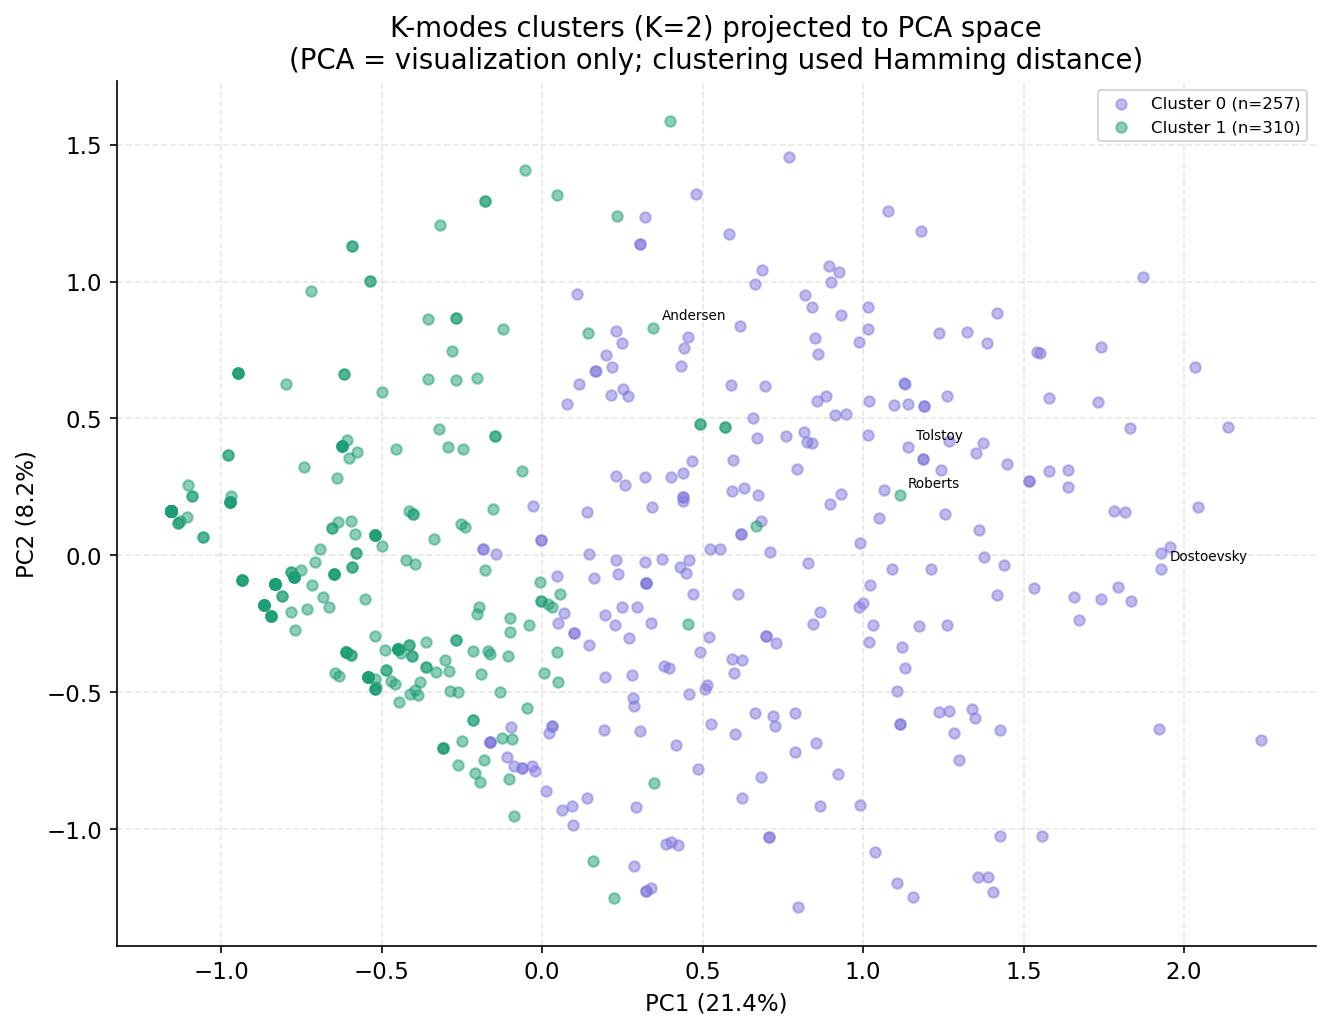

In [22]:
#8.5 PCA for visualisation (binary PCA via SVD on centered matrix)
# NOTE: PCA is still valid for VISUALIZATION of binary data (projects to 2D)
# even though the clustering itself used Hamming. We're not claiming PCA is
# the clustering method here.
X_centered = X_bin - X_bin.mean(axis=0)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_centered)
df['pca1'] = coords[:, 0]
df['pca2'] = coords[:, 1]

fig, ax = plt.subplots(figsize=(9, 7))
for c in range(K):
    m = df['cluster'] == c
    ax.scatter(df.loc[m,'pca1'], df.loc[m,'pca2'],
               alpha=0.5, s=25, color=CLUSTER_PAL[c % len(CLUSTER_PAL)],
               label=f'Cluster {c} (n={m.sum()})')
for c in range(K):
    top = df[df['cluster']==c].nlargest(2,'score')
    for _, row in top.iterrows():
        ax.annotate(row['author_name'].split()[-1],
                    (row['pca1'], row['pca2']), fontsize=6.5,
                    xytext=(4,4), textcoords='offset points')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'K-modes clusters (K={K}) projected to PCA space\n'
             '(PCA = visualization only; clustering used Hamming distance)',
             fontweight='500')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGS_DIR/'fig11_pca_clusters.png', bbox_inches='tight')
plt.show()

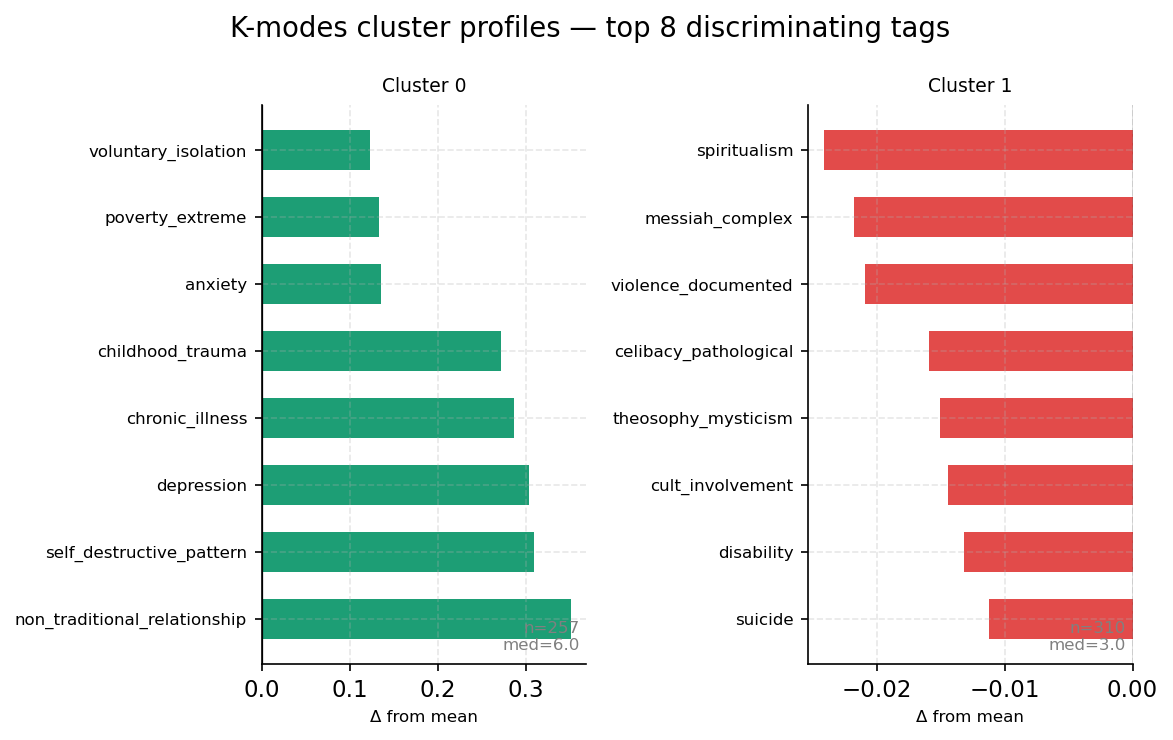

In [23]:
#8.6 Cluster profiles
overall_mean = X_bin.mean()

fig, axes = plt.subplots(1, K, figsize=(K*4, 5))
if K == 1: axes = [axes]

for c, ax in enumerate(axes):
    mask = df['cluster'] == c
    lift = (X_bin[mask].mean() - overall_mean).sort_values(ascending=False)
    lift.index = [TAG_SHORT[t] for t in lift.index]
    top8 = lift.head(8)
    colors = ['#1D9E75' if v>0 else '#E24B4A' for v in top8]
    ax.barh(range(len(top8)), top8.values, color=colors, height=0.6)
    ax.set_yticks(range(len(top8)))
    ax.set_yticklabels(top8.index, fontsize=8)
    ax.axvline(0, color='black', lw=0.6)
    ax.set_title(f'Cluster {c}', fontweight='500', fontsize=9)
    ax.set_xlabel('Δ from mean', fontsize=8)
    med = df.loc[mask,'score'].median()
    ax.text(0.98, 0.02, f'n={mask.sum()}\nmed={med:.1f}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='gray')

plt.suptitle('K-modes cluster profiles — top 8 discriminating tags',
             fontweight='500')
plt.tight_layout()
plt.savefig(FIGS_DIR/'fig12_cluster_profiles.png', bbox_inches='tight')
plt.show()


---
## 9. Original Hypotheses
**FIX: Holm correction + explicit confound notes**

In [24]:
# H1: Childhood trauma × high score × popularity
print('H1: Childhood trauma + high score + popularity')
if 'ratings_count' in df.columns and 'tag_childhood_trauma' in df.columns:
    top25_rc  = df['ratings_count'].quantile(0.75)
    popular   = df['ratings_count'] >= top25_rc
    trauma    = df['tag_childhood_trauma'] == True
    hi_score  = df['score'] >= 6
    sub       = df[hi_score & df['tag_childhood_trauma'].notna()]
    ct = pd.crosstab(sub['tag_childhood_trauma'].eq(True),
                     sub['ratings_count'].ge(top25_rc))
    ct.index   = ['No trauma','Trauma']
    ct.columns = ['Not popular','Popular (top 25%)']
    print(ct)
    if ct.shape == (2,2):
        _, p_chi = chi2_contingency(ct)[:2]
        OR, p_fish = fisher_exact(ct)
        print(f'Fisher: OR={OR:.2f}  p={p_fish:.4f}')
        print(' Confound note: popularity may reflect era (XIX authors have fewer'
              ' Goodreads ratings regardless of trauma status).')

=== H1: Childhood trauma + high score + popularity ===
           Not popular  Popular (top 25%)
No trauma           30                  6
Trauma             152                 52
Fisher: OR=1.71  p=0.2974
⚠ Confound note: popularity may reflect era (XIX authors have fewer Goodreads ratings regardless of trauma status).


In [25]:
# H2: Spiritualism paradox
print('=== H2: Spiritualism × score ===')
if 'tag_spiritualism' in df.columns:
    sub = df[df['tag_spiritualism'].notna()]
    sy = sub[sub['tag_spiritualism']==True]['score'].dropna()
    sn = sub[sub['tag_spiritualism']==False]['score'].dropna()
    u, p = mannwhitneyu(sy, sn, alternative='two-sided')
    print(f'True:  median={sy.median():.1f} IQR=[{sy.quantile(.25):.1f},{sy.quantile(.75):.1f}] n={len(sy)}')
    print(f'False: median={sn.median():.1f} IQR=[{sn.quantile(.25):.1f},{sn.quantile(.75):.1f}] n={len(sn)}')
    print(f'U={u:.0f}  p={p:.4f}')
    print('Interpretation: spiritualism co-occurs with other high-score tags'
          ' (childhood_trauma, non_traditional_relationship) — score difference'
          ' may reflect those, not spiritualism itself.')

=== H2: Spiritualism × score ===
True:  median=7.0 IQR=[6.0,7.0] n=21
False: median=4.0 IQR=[2.0,6.0] n=544
U=8263  p=0.0005
Interpretation: spiritualism co-occurs with other high-score tags (childhood_trauma, non_traditional_relationship) — score difference may reflect those, not spiritualism itself.


In [26]:
# ══════════════════════════════════════════════════════════════════════════
# H3: Privacy gap — null rates XIX vs XXI
# ══════════════════════════════════════════════════════════════════════════
print('H3: Privacy gap — null_rate by era')
null_era = df.groupby('era')['null_rate'].agg(['median','mean','std','count'])
print(null_era.round(3))

for e1, e2 in [('XIX','XXI'),('XX','XXI')]:
    g1 = df[df['era']==e1]['null_rate'].dropna()
    g2 = df[df['era']==e2]['null_rate'].dropna()
    if len(g1)>0 and len(g2)>0:
        u,p = mannwhitneyu(g1, g2, alternative='two-sided')
        print(f'{e1} vs {e2}: U={u:.0f}  p={p:.4f}')

=== H3: Privacy gap — null_rate by era ===
     median   mean    std  count
era                             
XIX     0.0  0.004  0.053    194
XX      0.0  0.000  0.000    193
XXI     0.0  0.011  0.104    180
XIX vs XXI: U=17355  p=0.5173
XX vs XXI: U=17177  p=0.1436


In [27]:
# H4: Suicide × popularity  ← CONFOUND NOTE
print('=== H4: Suicide/attempt × Goodreads popularity ===')
print()
print('CONFOUND WARNING!!!')
print('Tragic death → MORE posthumous biographies + MORE journalistic coverage')
print('→ HIGHER Goodreads ratings_count independent of literary quality.')
print('Any positive effect found here has 3 non-exclusive explanations:')
print('  (A) Psychological depth → better work → more readers [your hypothesis]')
print('  (B) Tragic fame effect  → death drives posthumous readership [confound]')
print('  (C) Selection bias      → suicidal authors get more biographies → higher conf → higher score')
print('You CANNOT distinguish A from B/C with this data.')
print('Recommended: report effect size + be explicit about all three interpretations.')
print()

if 'ratings_count' in df.columns:
    for tag in ['tag_suicide','tag_suicide_attempt']:
        if tag not in df.columns: continue
        sub = df[df[tag].notna() & df['ratings_count'].notna()]
        tv = sub[sub[tag]==True]['ratings_count'].values
        fv = sub[sub[tag]==False]['ratings_count'].values
        if len(tv)<5: continue
        u,p = mannwhitneyu(tv, fv, alternative='two-sided')
        print(f'{TAG_SHORT[tag]:20s}  True med={np.median(tv):,.0f}  '
              f'False med={np.median(fv):,.0f}  '
              f'ratio={np.median(tv)/np.median(fv):.2f}  p={p:.4f}  n_true={len(tv)}')

=== H4: Suicide/attempt × Goodreads popularity ===

⚠⚠ CONFOUND WARNING ⚠⚠
Tragic death → MORE posthumous biographies + MORE journalistic coverage
→ HIGHER Goodreads ratings_count independent of literary quality.
Any positive effect found here has 3 non-exclusive explanations:
  (A) Psychological depth → better work → more readers [your hypothesis]
  (B) Tragic fame effect  → death drives posthumous readership [confound]
  (C) Selection bias      → suicidal authors get more biographies → higher conf → higher score
You CANNOT distinguish A from B/C with this data.
Recommended: report effect size + be explicit about all three interpretations.

suicide               True med=340,768  False med=223,988  ratio=1.52  p=0.3758  n_true=10
suicide_attempt       True med=217,235  False med=224,124  ratio=0.97  p=0.8423  n_true=29


In [28]:
# H5: Top-50 vs 51–200 (survivorship within survivors)
print('H5: Rank tier × score')
if 'rank' in df.columns:
    t50  = df[df['rank']<=50]['score'].dropna()
    rest = df[df['rank']>50]['score'].dropna()
    u,p  = mannwhitneyu(t50, rest, alternative='two-sided')
    print(f'Top-50:  median={t50.median():.1f} IQR=[{t50.quantile(.25):.1f},{t50.quantile(.75):.1f}] n={len(t50)}')
    print(f'Rank 51+: median={rest.median():.1f} IQR=[{rest.quantile(.25):.1f},{rest.quantile(.75):.1f}] n={len(rest)}')
    print(f'U={u:.0f}  p={p:.4f}')

=== H5: Rank tier × score ===
Top-50:  median=6.0 IQR=[3.0,7.0] n=119
Rank 51+: median=4.0 IQR=[2.0,6.0] n=448
U=31676  p=0.0014


---
## 10. Sensitivity Analysis
**NEW: Re-run key tests on conf ≥ 0.65 and conf ≥ 0.75 subsets.**  
**If results hold → findings are robust to documentation quality.**  
**If results collapse → they may be an artefact of thin biographical records.**

In [29]:
#10.1 Subset sizes
for thr in [None, 0.65, 0.75]:
    sub = df if thr is None else df[df['conf'] >= thr]
    label = 'All' if thr is None else f'conf >= {thr}'
    print(f'{label:15s}: n={len(sub):4d}  '
          f'score median={sub["score"].median():.1f}  '
          f'IQR=[{sub["score"].quantile(.25):.1f},{sub["score"].quantile(.75):.1f}]')

All            : n= 567  score median=5.0  IQR=[3.0,6.0]
conf >= 0.65   : n= 538  score median=5.0  IQR=[3.0,6.0]
conf >= 0.75   : n= 445  score median=6.0  IQR=[4.0,7.0]


In [30]:
#10.2  Era differences: sensitivity
print('Era analysis sensitivity (Mann-Whitney XIX vs XX vs XXI)')
for thr, label in [(None,'All'),(0.65,'conf≥0.65'),(0.75,'conf≥0.75')]:
    sub = df if thr is None else df[df['conf']>=thr]
    pairs_s = list(combinations(valid_eras, 2))
    raw_ps  = []
    for e1, e2 in pairs_s:
        d1 = sub[sub['era']==e1]['score'].dropna()
        d2 = sub[sub['era']==e2]['score'].dropna()
        if len(d1)<5 or len(d2)<5:
            raw_ps.append(1.0); continue
        _, p = mannwhitneyu(d1, d2, alternative='two-sided')
        raw_ps.append(p)
    _, p_holm_s, _, _ = multipletests(raw_ps, method='holm')
    results_str = '  '.join([
        f'{e1}/{e2}: p={ph:.3f}{" *" if ph<0.05 else ""}'
        for (e1,e2), ph in zip(pairs_s, p_holm_s)
    ])
    print(f'[{label:12s}]  {results_str}')

=== Era analysis sensitivity (Mann-Whitney XIX vs XX vs XXI) ===
[All         ]  XIX/XX: p=0.323  XIX/XXI: p=0.000 *  XX/XXI: p=0.000 *
[conf≥0.65   ]  XIX/XX: p=0.562  XIX/XXI: p=0.000 *  XX/XXI: p=0.000 *
[conf≥0.75   ]  XIX/XX: p=0.939  XIX/XXI: p=0.000 *  XX/XXI: p=0.000 *


In [31]:
#10.3 Top-tag frequency: sensitivity
print('=== Top-5 tag frequency across confidence thresholds ===')
# Get top-5 tags overall
top5 = sorted([(t, df[t].eq(True).sum()) for t in TAGS if t in df.columns],
              key=lambda x: -x[1])[:5]

rows = []
for thr, label in [(None,'All'),(0.65,'conf≥0.65'),(0.75,'conf≥0.75')]:
    sub = df if thr is None else df[df['conf']>=thr]
    row = {'subset': label, 'n': len(sub)}
    for t, _ in top5:
        row[TAG_SHORT[t]] = f"{sub[t].eq(True).mean()*100:.1f}%"
    rows.append(row)

sens_df = pd.DataFrame(rows)
print(sens_df.to_string(index=False))
print()
print('Interpretation: if percentages are stable across subsets,')
print('the tag frequencies are not driven by low-quality biographical records.')

=== Top-5 tag frequency across confidence thresholds ===
   subset   n childhood_trauma chronic_illness non_traditional_relationship self_destructive_pattern depression
      All 567            63.4%           45.8%                        44.5%                    36.1%      34.7%
conf≥0.65 538            66.4%           47.8%                        46.4%                    37.9%      36.4%
conf≥0.75 445            69.9%           50.1%                        51.1%                    42.2%      41.8%

Interpretation: if percentages are stable across subsets,
the tag frequencies are not driven by low-quality biographical records.


---
## 11. Custom Tags Analysis
**NEW: custom_tags_json was never analysed in v1**

In [32]:
#11.1 Parse all custom tags
def parse_custom_tags(val):
    # pd.read_json может отдать уже список, или строку с JSON, или None
    if isinstance(val, list):
        items = val
    elif isinstance(val, str):
        try:
            items = json.loads(val)
        except:
            return []
    else:
        return []
    # Фильтруем: берём только словари, строки пропускаем
    return [x for x in items if isinstance(x, dict)]

if 'custom_tags_json' in df.columns:
    df['_custom_list'] = df['custom_tags_json'].apply(parse_custom_tags)

    custom_rows = []
    for _, row in df.iterrows():
        for ct in row['_custom_list']:
            custom_rows.append({
                'author':      row['author_name'],
                'era':         row['era'],
                'score':       row['score'],
                'conf':        row['conf'],
                'tag':         ct.get('tag', ''),
                'description': ct.get('description', ''),
                'evidence':    ct.get('evidence', ''),
            })

    ct_df = pd.DataFrame(custom_rows)
    if len(ct_df) == 0:
        print('⚠ No custom tags parsed — check custom_tags_json column format.')
    else:
        print(f'Total custom tag instances: {len(ct_df)}')
        print(f'Authors with ≥1 custom tag: {ct_df["author"].nunique()}')
        print(f'Unique custom tag names:    {ct_df["tag"].nunique()}')
else:
    print('custom_tags_json column not found.')
    ct_df = pd.DataFrame(columns=['author','era','score','conf','tag','description','evidence'])

Total custom tag instances: 942
Authors with ≥1 custom tag: 446
Unique custom tag names:    715


Top 25 custom tags:
tag_norm
mortality_driven_urgency                115
war_moral_transformation                 26
death_acceptance_transformation          20
diagnosis_triggered_liberation            9
mortality_driven_conversion               3
insomnia_as_creative_discipline           2
transgenerational_trauma_immersion        2
sustained_altruistic_engagement           2
situational_addiction_trigger             2
childhood_alter_ego                       2
justice_obsession                         2
creative_attrition_pattern                2
compulsive_perfectionism                  2
sarcasm_as_defense                        2
recovery_informed_memoirist               2
phobic_anxiety_as_creative_fuel           2
palmistry_practice                        2
political_moratorium_emigration           2
provocative_performance_ritual            2
trauma_triggered_social_wariness          2
workaholic_disorder                       2
public_figure_backlash                    2
dom

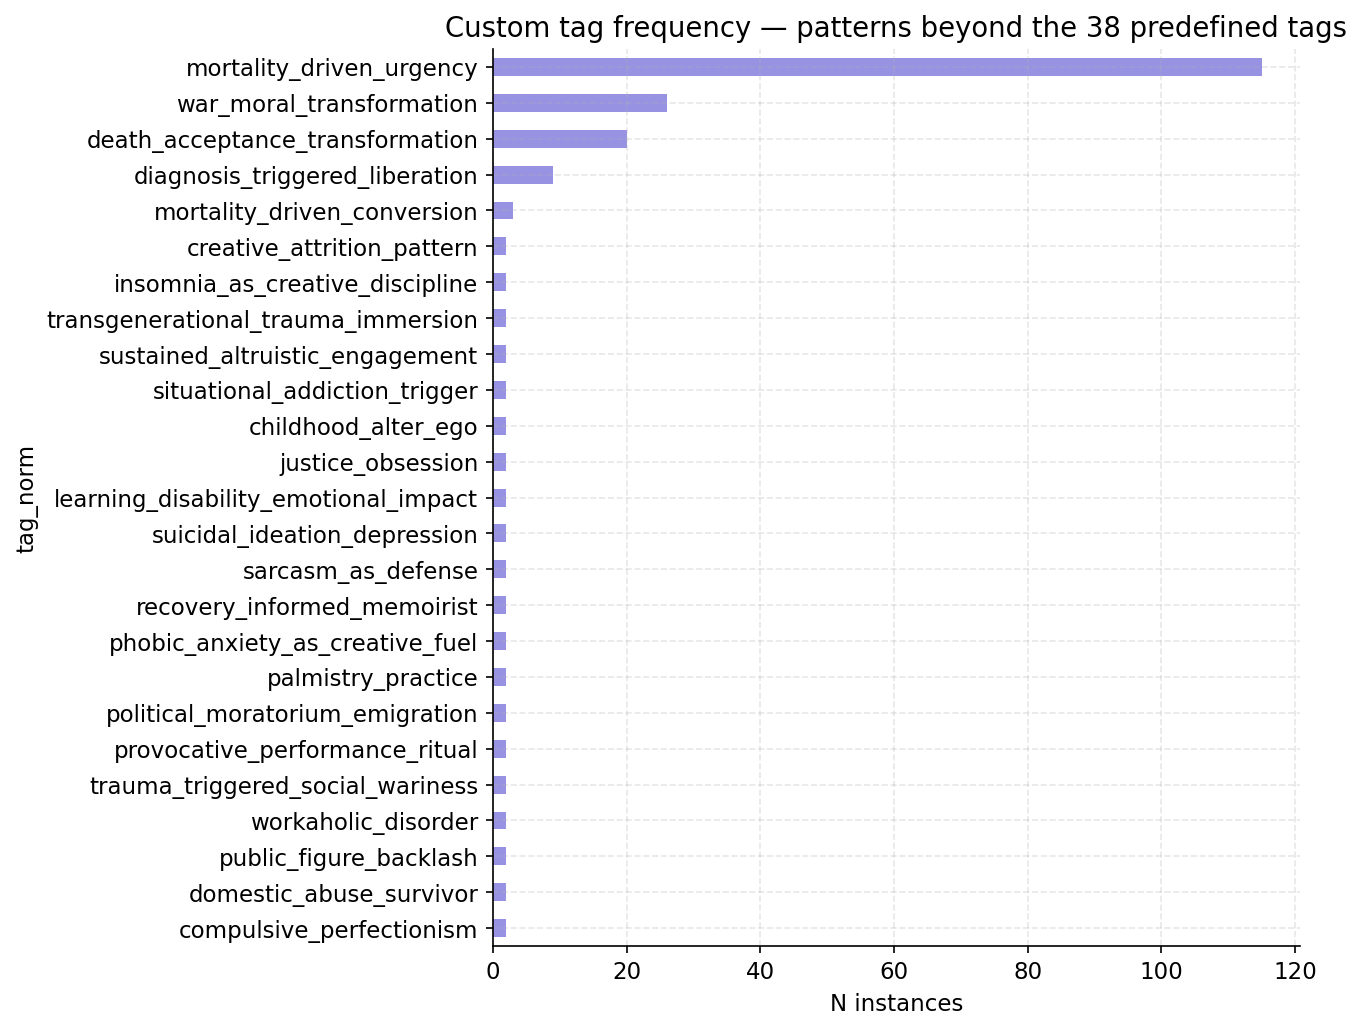


Sample evidence for top-3 custom tags:

--- mortality_driven_urgency ---
  Jane Austen: During the last 18 months of her life, while suffering from what is now believed to be Addison's disease, Austen complet
  Charles Dickens: After a mild stroke in 1869, Dickens ignored medical advice and embarked on a final reading tour, writing to John Forste
  H.G. Wells: Following a lung haemorrhage and suspected tuberculosis diagnosis in 1888, and another in 1893, Wells, realizing he coul

--- war_moral_transformation ---
  Joseph Conrad: His 1890 Congo journey, documented in his Congo Diary, exposed him to atrocities that led to a nervous breakdown upon re
  Leo Tolstoy: 1857 letter to Vasily Botkin after witnessing a public execution in Paris: 'The truth is that the State is a conspiracy 
  Jerome K. Jerome: Biographical sources state: 'The war experience was said to have changed him, as did the death of his stepdaughter, Elsi

--- death_acceptance_transformation ---
  Alexandre Dumas: biogra

In [33]:
#11.2 Top custom tags by frequency
if len(ct_df) > 0:
    # Normalize snake_case names
    ct_df['tag_norm'] = ct_df['tag'].str.lower().str.strip().str.replace(' ','_')

    freq = ct_df['tag_norm'].value_counts().head(25)
    print('Top 25 custom tags:')
    print(freq.to_string())

    fig, ax = plt.subplots(figsize=(9, 7))
    freq.sort_values().plot.barh(ax=ax, color='#7F77DD', alpha=0.8)
    ax.set_xlabel('N instances')
    ax.set_title('Custom tag frequency — patterns beyond the 38 predefined tags',
                 fontweight='500')
    plt.tight_layout()
    plt.savefig(FIGS_DIR/'fig13_custom_tag_freq.png', bbox_inches='tight')
    plt.show()

    # Show sample evidence for top-3 tags
    print('\nSample evidence for top-3 custom tags:')
    for tag in freq.head(3).index:
        print(f'\n--- {tag} ---')
        sample = ct_df[ct_df['tag_norm']==tag][['author','evidence']].head(3)
        for _, row in sample.iterrows():
            print(f'  {row["author"]}: {str(row["evidence"])[:120]}')

In [34]:
#11.3  Custom tags by era
if len(ct_df) > 0:
    # Average number of custom tags per author by era
    custom_per_author = ct_df.groupby('author').size().reset_index(name='n_custom')
    df_custom = df.merge(custom_per_author, left_on='author_name',
                         right_on='author', how='left')
    df_custom['n_custom'] = df_custom['n_custom'].fillna(0)

    print('Custom tags per author by era (median)')
    print(df_custom.groupby('era')['n_custom'].agg(['median','mean','count']).round(2))
    print()
    print('Interpretation: if XIX authors have more custom tags on average,')
    print('this reflects richer documentation enabling more nuanced annotation,'
          ' not necessarily more unusual behavior.')

=== Custom tags per author by era (median) ===
     median  mean  count
era                     
XIX     2.0  1.69    194
XX      2.0  2.23    193
XXI     1.5  1.68    180

Interpretation: if XIX authors have more custom tags on average,
this reflects richer documentation enabling more nuanced annotation, not necessarily more unusual behavior.


---
## 12. Text Profiles (TF-IDF on life_pattern_summary)
**NEW: Qualitative complement to quantitative clusters**

In [35]:
# 12.1  TF-IDF word profiles by era
if 'life_pattern_summary' in df.columns:
    from sklearn.feature_extraction.text import TfidfVectorizer

    # Fill missing
    df['summary_clean'] = df['life_pattern_summary'].fillna('').str.lower()

    # Top words per era — concatenate all summaries per era, then TF-IDF
    era_docs = {}
    for e in valid_eras:
        texts = df[df['era']==e]['summary_clean'].tolist()
        era_docs[e] = ' '.join(texts)

    if any(era_docs.values()):
        tfidf = TfidfVectorizer(
            max_features=200, ngram_range=(1,2),
            stop_words='english',
            token_pattern=r'[a-zA-Z]{3,}(?:\s[a-zA-Z]{3,})?'
        )
        era_names = list(era_docs.keys())
        matrix = tfidf.fit_transform(list(era_docs.values()))
        words  = tfidf.get_feature_names_out()
        tfidf_df = pd.DataFrame(matrix.toarray(), index=era_names, columns=words)

        print('Top TF-IDF terms per era')
        for e in era_names:
            top = tfidf_df.loc[e].sort_values(ascending=False).head(15)
            print(f'\n{e}: ' + ' | '.join(top.index.tolist()))
else:
    print('life_pattern_summary column not found — skipping text analysis.')

=== Top TF-IDF terms per era ===

XIX: self | marked | psychological profile | pattern | defined | life was | life | psychological profile defined | life was marked | followed | death | his psychological | his life | led | leading

XX: psychological profile | marked | defined | self | pattern | psychological profile defined | life | life was | trauma | leading | non | death | followed | his life | life was marked

XXI: life | self | psychological profile | marked | pattern | defined | characterized | long | non | documented | term marriage | documented psychological | psychological profile defined | life characterized | life documented


In [36]:
#12.2 TF-IDF word profiles by cluster
if ('life_pattern_summary' in df.columns and 'cluster' in df.columns
        and 'summary_clean' in df.columns):   # guard: §12.1 must have run
    cluster_docs = {}
    for c in sorted(df['cluster'].unique()):
        texts = df[df['cluster']==c]['summary_clean'].tolist()
        cluster_docs[c] = ' '.join(texts)

    if any(cluster_docs.values()):
        tfidf_c = TfidfVectorizer(
            max_features=200, ngram_range=(1,2),
            stop_words='english',
            token_pattern=r'[a-zA-Z]{3,}(?:\s[a-zA-Z]{3,})?'
        )
        c_names = list(cluster_docs.keys())
        mat_c   = tfidf_c.fit_transform(list(cluster_docs.values()))
        words_c = tfidf_c.get_feature_names_out()
        tfidf_c_df = pd.DataFrame(mat_c.toarray(), index=c_names, columns=words_c)

        print('Top TF-IDF terms per cluster')
        print('(Use these to name your clusters!)')
        for c in c_names:
            top = tfidf_c_df.loc[c].sort_values(ascending=False).head(12)
            n = (df['cluster']==c).sum()
            print(f'\nCluster {c} (n={n}): ' + ' | '.join(top.index.tolist()))

=== Top TF-IDF terms per cluster ===
(Use these to name your clusters!)

Cluster 0 (n=257): psychological profile | pattern | self | marked | defined | psychological profile defined | life was | followed | life | leading | life was marked | death

Cluster 1 (n=310): life | self | marked | psychological profile | defined | characterized | non | long | documented psychological | evidence | pattern | pathology


---
## 13. Export

In [37]:
#13.1  Top-20 authors 
top_cols = [c for c in ['author_name','era','score','conf','evidence_quality',
                        'gender','cluster','most_defining_trait'] if c in df.columns]
top20 = df.nlargest(20,'score')[top_cols]
print('Top-20 Authors by Score')
print(top20.to_string(index=False))
top20.to_csv('top20_authors.csv', index=False)

=== Top-20 Authors by Score ===
            author_name era  score  conf evidence_quality gender  cluster                                                                                                                                                                                                                                                   most_defining_trait
            Leo Tolstoy XIX    9.0  0.80       documented      M        0                                                                                                                                                                             messianic self-perception combined with documented lifelong self-loathing about sexuality
      Fyodor Dostoevsky XIX    9.0  0.82       documented      M        0                                                                                                            Documented transformation from mock execution trauma and lifelong epilepsy with ecstatic auras, shaping his entire 

In [38]:
#13.2 Summary stats for paper
s = df['score']
summary = [
    ('N total', len(df_raw)),
    ('N with score', len(df)),
    ('Score median', s.median()),
    ('Score IQR', f'[{s.quantile(.25):.1f}, {s.quantile(.75):.1f}]'),
    ('Score mean (secondary)', round(s.mean(),2)),
    ('% score >= 5', f'{(s>=5).mean()*100:.1f}%'),
    ('% score >= 7', f'{(s>=7).mean()*100:.1f}%'),
    ('Conf median', round(df["conf"].median(),3)),
    ('N XIX', int((df["era"]=="XIX").sum())),
    ('N XX',  int((df["era"]=="XX").sum())),
    ('N XXI', int((df["era"]=="XXI").sum())),
    ('N conf >= 0.65', int((df["conf"]>=0.65).sum())),
    ('N conf >= 0.75', int((df["conf"]>=0.75).sum())),
]
summ_df = pd.DataFrame(summary, columns=['Metric','Value'])
print(summ_df.to_string(index=False))
summ_df.to_csv('paper_summary_stats.csv', index=False)

                Metric      Value
               N total        600
          N with score        567
          Score median        5.0
             Score IQR [3.0, 6.0]
Score mean (secondary)       4.61
          % score >= 5      50.3%
          % score >= 7      23.5%
           Conf median        0.8
                 N XIX        194
                  N XX        193
                 N XXI        180
        N conf >= 0.65        538
        N conf >= 0.75        445


In [39]:
#13.3  Final annotated dataset 
export_cols = ['author_name','era','decade','score','conf','evidence_quality',
               'gender','cluster','null_rate'] + \
              [c for c in df.columns if c.startswith('tag_')]
export_cols = [c for c in export_cols if c in df.columns]
df[export_cols].to_csv('authors_final_analysis_v2.csv', index=False)
print(f'Saved authors_final_analysis_v2.csv ({len(df)} rows)')
print('\n=== Figures saved ===')
for p in sorted(FIGS_DIR.iterdir()):
    print(f'  {p.name}')

Saved authors_final_analysis_v2.csv (567 rows)

=== Figures saved ===
  fig01_tag_coverage.png
  fig02_score_distribution.png
  fig03_era_boxplot.png
  fig04_gender_tag_gap.png
  fig05_gender_confidence.png
  fig06_cooccurrence_heatmap.png
  fig07_score_by_decade.png
  fig08_temporal_tags.png
  fig09_tag_ratings_effect.png
  fig10_kmodes_selection.png
  fig11_pca_clusters.png
  fig12_cluster_profiles.png
  fig13_custom_tag_freq.png


---
## Methodological Notes (for paper Methods section)

| Issue | v1 approach | v2 fix | Impact |
|---|---|---|---|
| Clustering on binary data | K-means (Euclidean) | K-modes (Hamming) | Clusters are now geometrically meaningful |
| Co-occurrence with nulls | `eq(True)` maps null→0 | Null-masked Jaccard | Rare tags no longer artificially low |
| Multiple testing | No correction | Holm–Bonferroni | Removes ~2 false positives per 38-test block |
| Score as interval | mean ± SEM | median + IQR (primary) | Honest representation of ordinal data |
| Era confound in corr. | Naive Spearman | Partial Spearman (era) | Separates era effect from psychology effect |
| H4 confound | Not mentioned | Explicit 3-interpretation note | Prevents overclaiming |
| Gender non-Western bias | Not flagged | Unknown-rate audit + sensitivity | Honest scope limitation |
| Low-conf artefacts | All authors equal | Sensitivity at 0.65/0.75 | Robustness check |

**Remaining limitations (cannot be fixed with current data):**
- Survivorship bias: only successful authors are in the sample
- Posthumous diagnosis: all historical annotation is retrospective
- Single annotator (LLM): no human inter-rater reliability check
- Wikipedia as source: quality varies by author nationality/fame

---
## 14. Predictive Modelling — Logistic Regression
**Goal: predict high standardness score (≥ 5) from 38 binary tags.**  
Provides feature importance, odds ratios, and cross-validated ROC-AUC.  
This section demonstrates that the tag profile has genuine discriminative power.


In [40]:
#14.1 Data preparation 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, roc_curve

# Binary target: score >= 5 (high non-standardness)
y = (df['score'] >= 5).astype(int)

# Features: same tag set used in clustering (>= 10 True values)
# cluster_tags is already defined in §8.2
feature_tags = cluster_tags
X_lr = df[feature_tags].eq(True).fillna(False).astype(int)

print(f'Features : {X_lr.shape[1]} binary tags')
print(f'Samples  : {X_lr.shape[0]}')
print(f'Target   : {y.mean()*100:.1f}% high-score (≥5)  |  {(1-y.mean())*100:.1f}% low-score (<5)')

# ── 14.2  Cross-validation (5-fold stratified) 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)

roc_scores = cross_val_score(lr, X_lr, y, cv=cv, scoring='roc_auc')
acc_scores  = cross_val_score(lr, X_lr, y, cv=cv, scoring='accuracy')

print(f'\n=== 5-fold cross-validation ===')
print(f'ROC-AUC  : {roc_scores.mean():.3f} ± {roc_scores.std():.3f}')
print(f'Accuracy : {acc_scores.mean():.3f} ± {acc_scores.std():.3f}')
print()

#14.3 Final model on full data 
# NOTE: full-data metrics are optimistic — always report CV results in paper.
lr.fit(X_lr, y)

# Build coefficient / odds-ratio table
coef_df = pd.DataFrame({
    'tag'        : [t.replace('tag_', '') for t in feature_tags],
    'coef'       : lr.coef_[0],
    'odds_ratio' : np.exp(lr.coef_[0])
}).sort_values('coef', ascending=False).reset_index(drop=True)

print('Top-10 positive predictors  (OR > 1 → associated with high score)')
print(coef_df.head(10)[['tag', 'coef', 'odds_ratio']].round(3).to_string(index=False))
print()
print('Top-10 negative predictors  (OR < 1 → associated with low score)')
print(coef_df.tail(10)[['tag', 'coef', 'odds_ratio']].round(3).to_string(index=False))


Features : 32 binary tags
Samples  : 567
Target   : 50.3% high-score (≥5)  |  49.7% low-score (<5)

=== 5-fold cross-validation ===
ROC-AUC  : 0.941 ± 0.015
Accuracy : 0.866 ± 0.022

=== Top-10 positive predictors  (OR > 1 → associated with high score) ===
                         tag  coef  odds_ratio
    self_destructive_pattern 1.619       5.048
             extremist_views 1.482       4.402
     homosexuality_taboo_era 1.387       4.005
            childhood_trauma 1.385       3.996
             substance_abuse 1.332       3.789
                  depression 1.291       3.638
non_traditional_relationship 1.156       3.176
                imprisonment 1.148       3.152
              legal_troubles 0.984       2.676
           nihilism_explicit 0.983       2.674

=== Top-10 negative predictors  (OR < 1 → associated with low score) ===
                  tag   coef  odds_ratio
      chronic_illness  0.504       1.656
      poverty_extreme  0.494       1.639
           disability  0.420 

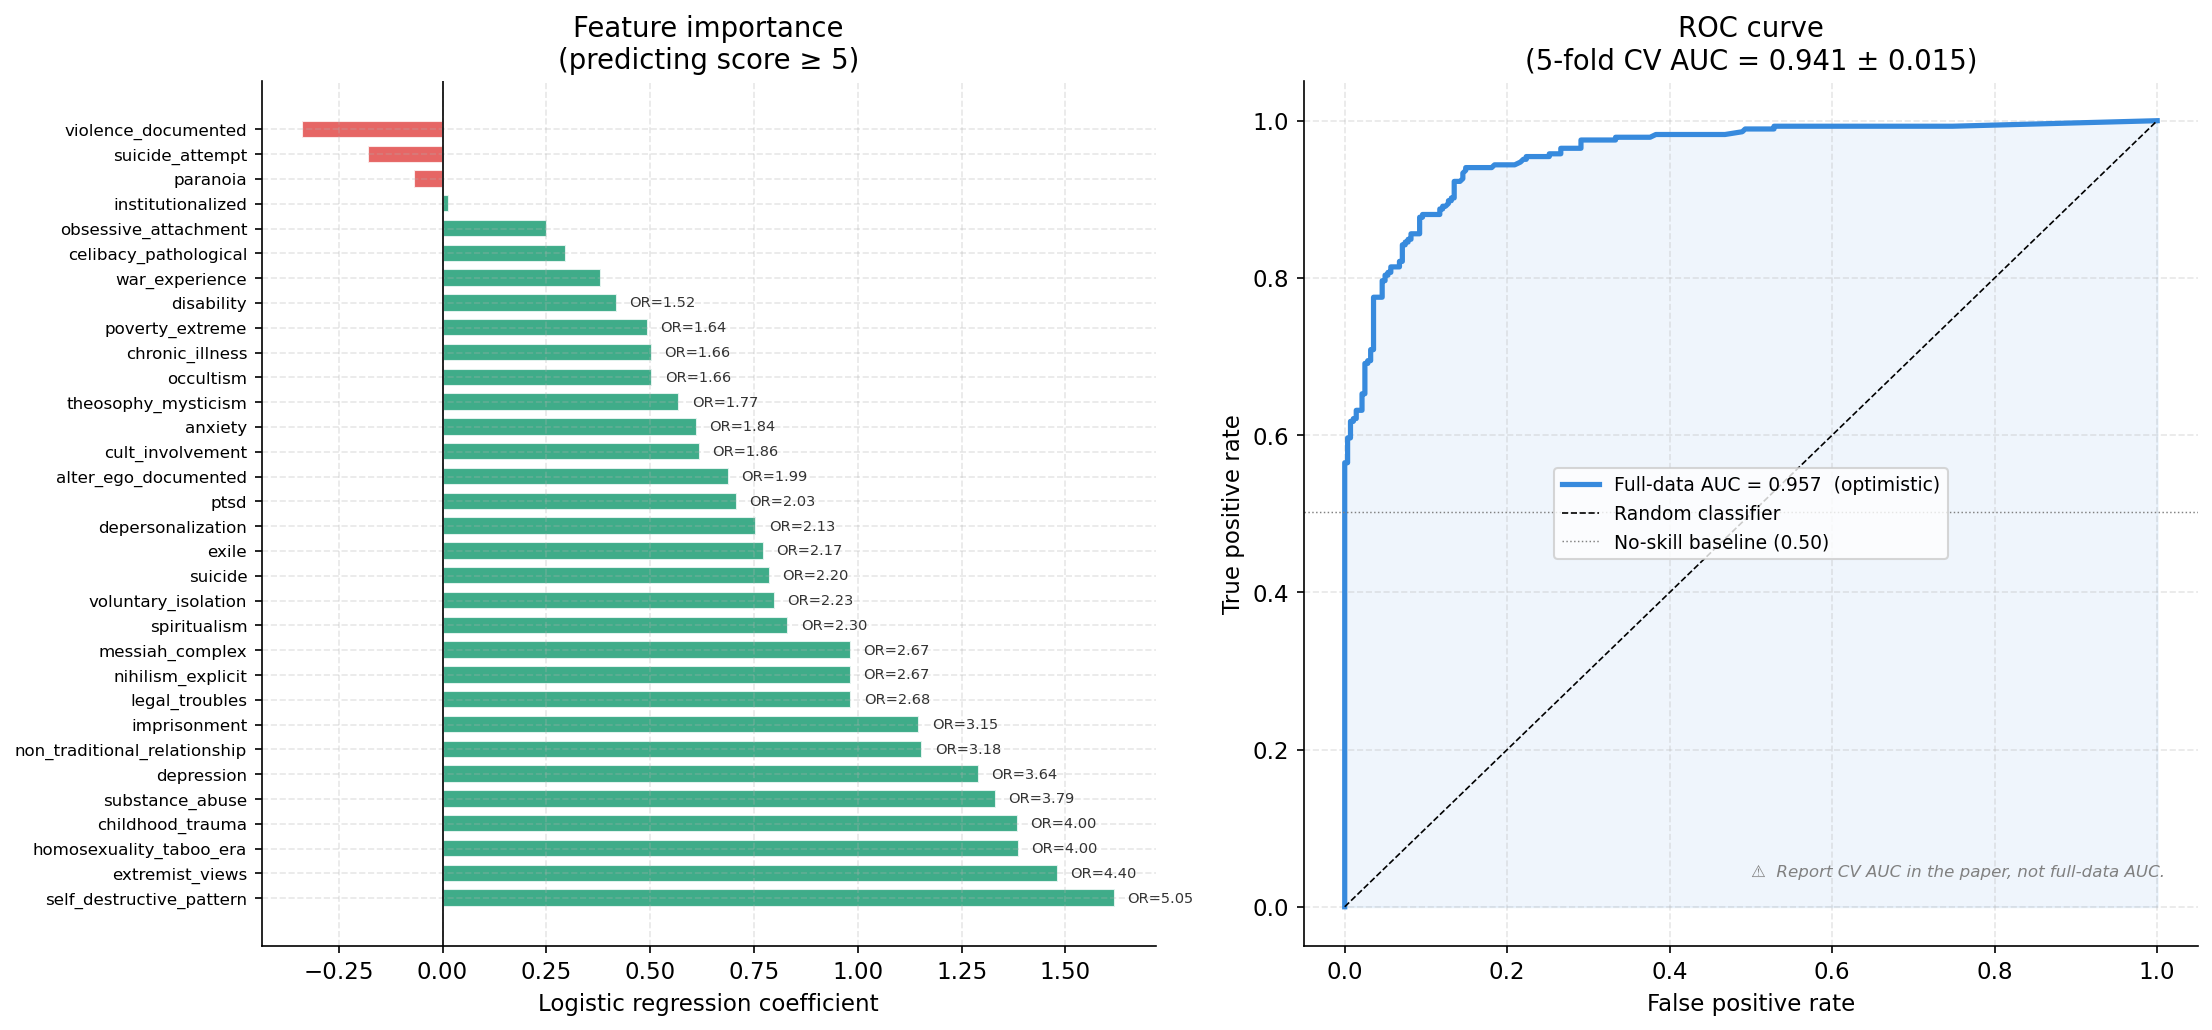

Saved: fig14_logreg_importance.png

=== Model interpretation ===
CV AUC = 0.941  →  good (AUC ≥ 0.75) — binary tags alone meaningfully predict high non-standardness

Top-3 positive: self_destructive_pattern, extremist_views, homosexuality_taboo_era
Top-3 negative: violence_documented, suicide_attempt, paranoia


In [41]:
# ── 14.4  Feature importance plot + ROC curve ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# ── Left panel: coefficient bar chart ────────────────────────────────────
ax = axes[0]
colors = ['#1D9E75' if v > 0 else '#E24B4A' for v in coef_df['coef']]
ax.barh(coef_df['tag'], coef_df['coef'],
        color=colors, height=0.7, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Logistic regression coefficient')
ax.set_title('Feature importance\n(predicting score ≥ 5)',
             fontweight='500')
ax.tick_params(axis='y', labelsize=8)

# Annotate odds ratios on the largest bars
for _, row in coef_df.iterrows():
    if abs(row['coef']) >= 0.4:
        xpos = row['coef'] + (0.03 if row['coef'] > 0 else -0.03)
        ha   = 'left' if row['coef'] > 0 else 'right'
        ax.text(xpos, row.name, f"OR={row['odds_ratio']:.2f}",
                va='center', ha=ha, fontsize=7, color='#333333')

# ── Right panel: ROC curve ────────────────────────────────────────────────
ax2 = axes[1]
y_prob   = lr.predict_proba(X_lr)[:, 1]
fpr, tpr, _ = roc_curve(y, y_prob)
auc_full = roc_auc_score(y, y_prob)

ax2.plot(fpr, tpr, color='#378ADD', lw=2.5,
         label=f'Full-data AUC = {auc_full:.3f}  (optimistic)')
ax2.fill_between(fpr, tpr, alpha=0.08, color='#378ADD')
ax2.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random classifier')
ax2.axhline(y.mean(), color='gray', lw=0.7, linestyle=':',
            label=f'No-skill baseline ({y.mean():.2f})')
ax2.set_xlabel('False positive rate')
ax2.set_ylabel('True positive rate')
ax2.set_title(f'ROC curve\n(5-fold CV AUC = {roc_scores.mean():.3f} ± {roc_scores.std():.3f})',
              fontweight='500')
ax2.legend(fontsize=9)
ax2.text(0.50, 0.08,
         '  Report CV AUC in the paper, not full-data AUC.',
         transform=ax2.transAxes, fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig14_logreg_importance.png', bbox_inches='tight')
plt.show()
print('Saved: fig14_logreg_importance.png')

# ── 14.5  Interpretation summary ──────────────────────────────────────────
print(f'\n=== Model interpretation ===')
cv_auc = roc_scores.mean()
if cv_auc >= 0.75:
    level = 'good (AUC ≥ 0.75) — binary tags alone meaningfully predict high non-standardness'
elif cv_auc >= 0.65:
    level = 'moderate (0.65 ≤ AUC < 0.75) — tags have some predictive signal'
else:
    level = 'weak (AUC < 0.65) — tags alone are insufficient predictors; score has independent variance'
print(f'CV AUC = {cv_auc:.3f}  →  {level}')

# Top-3 positive and negative predictors for paper
top3_pos = coef_df.head(3)
top3_neg = coef_df.tail(3)
print(f'\nTop-3 positive: {", ".join(top3_pos["tag"].tolist())}')
print(f'Top-3 negative: {", ".join(top3_neg["tag"].tolist()[::-1])}')
